# Copenhagen Housing Price Model

Hierarchical Bayesian model of residential sqm prices across 9 Copenhagen districts (1992–2024), with a 2026–2060 forecast driven by Statistics Denmark population projections.

**Data sources**
- Housing transactions: [Kaggle – Danish Residential Housing Prices 1992–2024](https://www.kaggle.com/datasets/martinfrederiksen/danish-residential-housing-prices-1992-2024)
- Socioeconomic panel: Statistics Denmark (KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026)

### Table of Contents
1. [Phase 1 - Data Ingestion & EDA](#phase-1---data-ingestion--eda)
    * Task 1.1 Housing transaction data - Tomas
    * Task 1.2 & Task 1.3 Statistics Denmark - David
2. [Phase 2 - Feature Engineering](#phase-2---feature-engineering)
    * Task 2.1 Aggregate housing prices to district-year level & 2.2 Align district names & 2.3 Join raw transactions with panel & 2.4 Join housing aggregates - Ursula
    * Task 2.5 - Reduce covariates
    * Task 2.6 - Feature EDA
3. Phase 3 - PGM design
4. Phase 4 - Pyro implementation 
5. Phase 5 - Inference 
6. Phase 6 - Results & 2026-2060 forecast

### Possible Project Plan
![image.png](attachment:image.png)
![image-2.png](attachment:image-2.png)
![image-3.png](attachment:image-3.png)
![image-4.png](attachment:image-4.png)
![image-5.png](attachment:image-5.png)
![image-6.png](attachment:image-6.png)

In [1]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import sys, pyarrow as pa
print(sys.executable)
print("pandas:", pd.__version__)
print("pyarrow:", pa.__version__)

/usr/local/bin/python3
pandas: 2.3.3
pyarrow: 23.0.1


## Phase 1 - Data Ingestion & EDA
### 1.1 Housing transaction data
Load the Kaggle parquet, filter to Copenhagen zip codes (1000–2720), and map zip codes to the 10 Copenhagen districts used by Statistics Denmark. Basic EDA: sales counts per district, price distributions, and temporal trends.

In [2]:
df = pd.read_parquet('data/DKHousingPrices.parquet', engine='pyarrow')
df['date'] = pd.to_datetime(df['date'])
print("Original shape:", df.shape)

mask = df['zip_code'].between(1000, 2720)
print("Rows matching København:", mask.sum())

df = df[mask].copy()

# Map postal codes to neighborhoods using ranges
def map_zip_to_district(zip_code):
    # Indre By (City Center)
    if 1000 <= zip_code <= 1499:
        return 'Indre By'
    
    # Østerbro
    elif zip_code in [2100, 2150]:
        return 'Østerbro'
    
    # Nørrebro
    elif 2200 <= zip_code <= 2204:
        return 'Nørrebro'
    
    # Vesterbro/Kongens Enghave (includes Sydhavn 2450)
    elif 1500 <= zip_code <= 1799 or zip_code == 2450:
        return 'Vesterbro'
    
    # Valby
    elif zip_code == 2500:
        return 'Valby'
    
    # Vanløse
    elif zip_code == 2720:
        return 'Vanløse'
    
    # Brønshøj-Husum
    elif zip_code == 2700:
        return 'Brønshøj-Husum'
    
    # Bispebjerg (includes Nordvest)
    elif 2400 <= zip_code <= 2404:
        return 'Bispebjerg'
    
    # Amager Øst & Vest
    elif zip_code == 2300:
        return 'Amager'
    
    # Frederiksberg (Separate municipality, but often grouped)
    elif zip_code == 2000 or 1800 <= zip_code <= 1999:
        return 'Frederiksberg'
        
    return None
df['neighborhood'] = df['zip_code'].apply(map_zip_to_district)

# Show unmatched postal codes
unmatched = df[df['neighborhood'].isna()]['zip_code'].unique()
if len(unmatched) > 0:
    print(f"Unmatched postal codes: {sorted(unmatched)}")

df.drop(columns=['quarter', 'house_id', 'city', 'area', 'region'], inplace=True, errors='ignore')
df.reset_index(drop=True, inplace=True)
df.head()

Original shape: (1507908, 19)
Rows matching København: 150382
Unmatched postal codes: [np.int16(2600), np.int16(2605), np.int16(2610), np.int16(2620), np.int16(2625), np.int16(2630), np.int16(2635), np.int16(2640), np.int16(2650), np.int16(2660), np.int16(2665), np.int16(2670), np.int16(2680), np.int16(2690)]


,date,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%,neighborhood
0,2024-10-24,Villa,regular_sale,1997,6500000,-3.0,5,142.0,45774.648438,Spættevej 16,2680,3.1,NaN,NaN,None
1,2024-10-24,Apartment,regular_sale,2006,4115000,0.0,3,77.0,53441.558594,"Teglholmsgade 8B, 3. th",2450,3.1,NaN,NaN,Vesterbro
2,2024-10-24,Apartment,regular_sale,1885,3400000,0.0,2,46.0,73913.046875,"Jakob Dannefærds Vej 10B, 4. th",1973,3.1,NaN,NaN,Frederiksberg
3,2024-10-24,Villa,family_sale,1929,4750000,0.0,4,118.0,40254.238281,Herfølgevej 19,2700,3.1,NaN,NaN,Brønshøj-Husum
4,2024-10-23,Villa,regular_sale,1949,4550000,-4.0,4,112.0,40625.000000,Vestre Plantagevej 3,2680,3.1,NaN,NaN,None


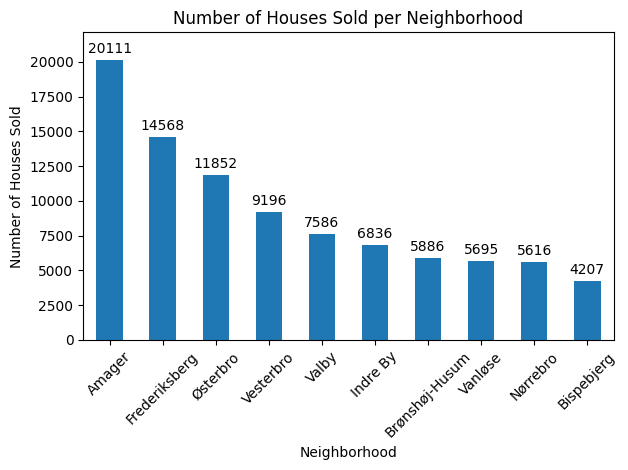

In [3]:
ax = df['neighborhood'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0], padding=3)
plt.title('Number of Houses Sold per Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Number of Houses Sold')
plt.ylim(0, df['neighborhood'].value_counts().max() * 1.1)
plt.xticks(rotation=45)
plt.tight_layout()

In [4]:
df.groupby('neighborhood')['purchase_price'].agg(['mean', 'median', 'std'])

,mean,median,std
neighborhood,,,
Amager,3.274996e+06,2895000.0,2.067358e+06
Bispebjerg,2.536727e+06,2150000.0,1.626489e+06
Brønshøj-Husum,2.814610e+06,2400000.0,1.808526e+06
Frederiksberg,3.793048e+06,3300000.0,2.483333e+06
Indre By,4.280457e+06,3700000.0,2.803818e+06
Nørrebro,2.743367e+06,2469000.0,1.647398e+06
Valby,3.051307e+06,2660000.0,2.030047e+06
Vanløse,2.810252e+06,2330000.0,1.887941e+06
Vesterbro,3.956808e+06,3642085.5,2.271774e+06


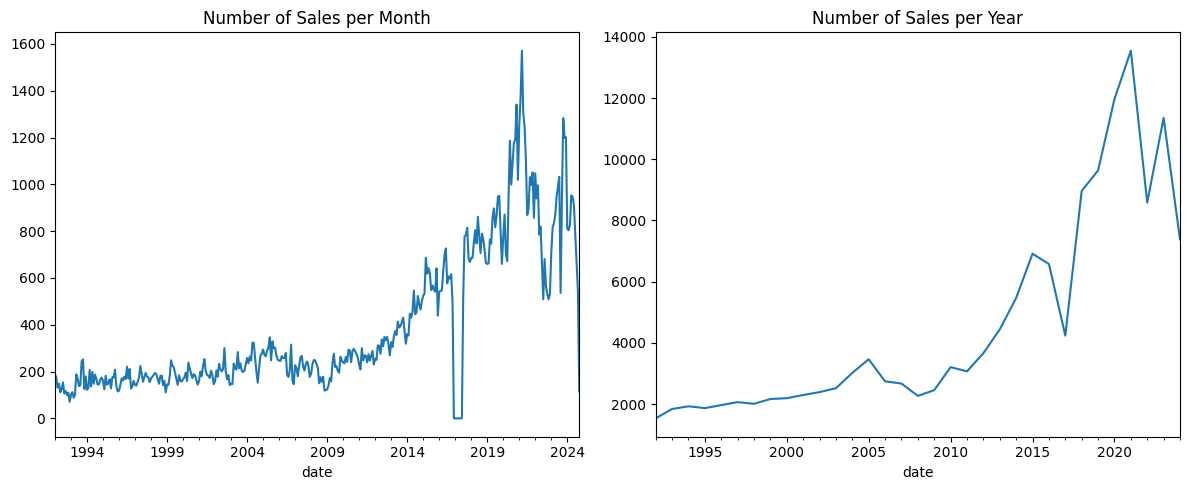

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

ts = df.set_index('date').resample('D').size()  # Daily counts of sales

# By month
ts_month = ts.resample('MS').sum()  # MS = month start
ts_month.plot(ax=axes[0])
axes[0].set_title('Number of Sales per Month')

# By year
ts_year = ts.resample('YS').sum()   # YS = year start
ts_year.plot(ax=axes[1])
axes[1].set_title('Number of Sales per Year')

plt.tight_layout()
plt.show()

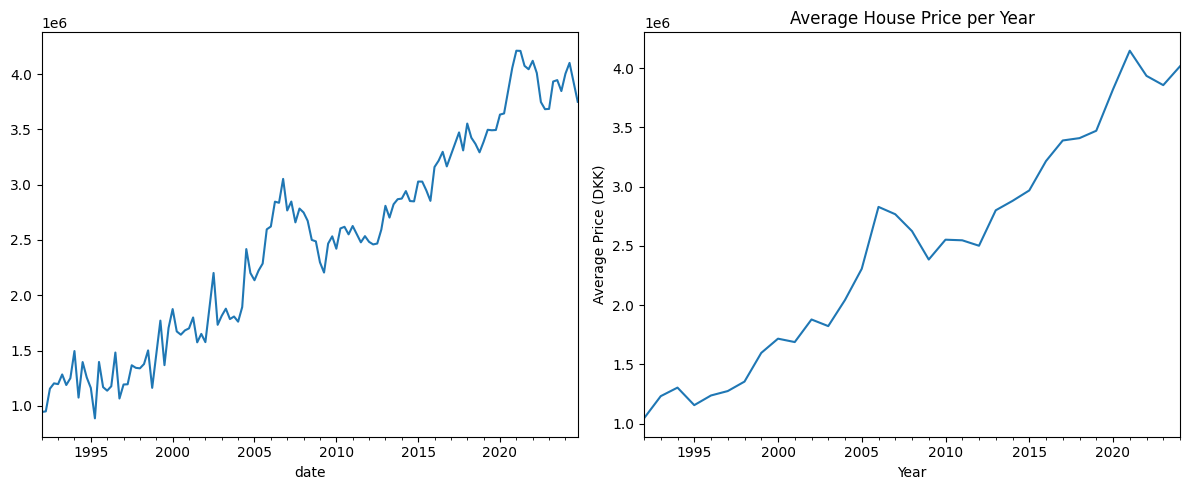

In [6]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
# Average house price per quarter
avg_price_quarter = df.groupby(df['date'].dt.to_period('Q'))['purchase_price'].mean()
avg_price_quarter.plot(ax=axes[0])
plt.title('Average House Price per Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Price (DKK)')
plt.tight_layout()



avg_price_year = df.groupby(df['date'].dt.to_period('Y'))['purchase_price'].mean()
avg_price_year.plot(ax=axes[1])
plt.title('Average House Price per Year')
plt.xlabel('Year')
plt.ylabel('Average Price (DKK)')
plt.tight_layout()
plt.show()

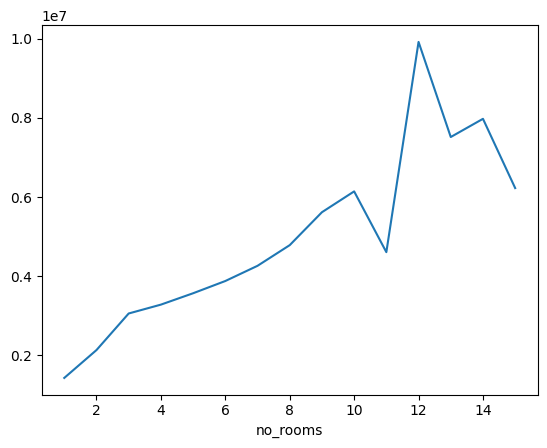

In [7]:
df.groupby('no_rooms')['purchase_price'].mean().plot();

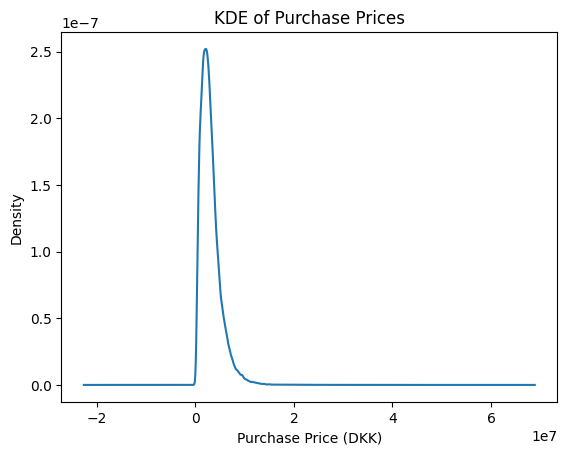

In [8]:
# KDE plot for purchase_price in 2024
df['purchase_price'].plot(kind='kde')
plt.title('KDE of Purchase Prices')
plt.xlabel('Purchase Price (DKK)')
plt.ylabel('Density')
plt.show()

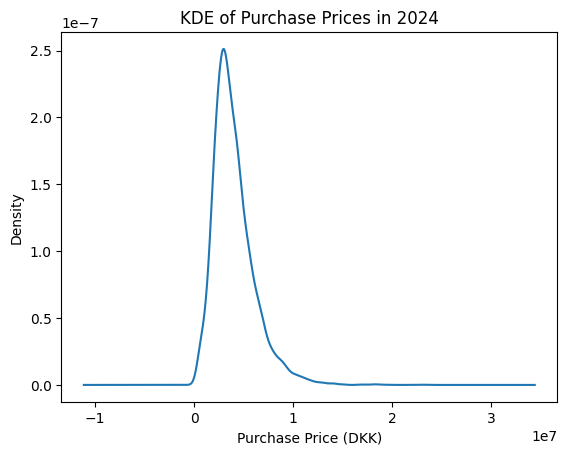

In [9]:
# KDE plot for purchase_price in 2024
df[df['date'] >= '2024-01-01']['purchase_price'].plot(kind='kde')
plt.title('KDE of Purchase Prices in 2024')
plt.xlabel('Purchase Price (DKK)')
plt.ylabel('Density')
plt.show()

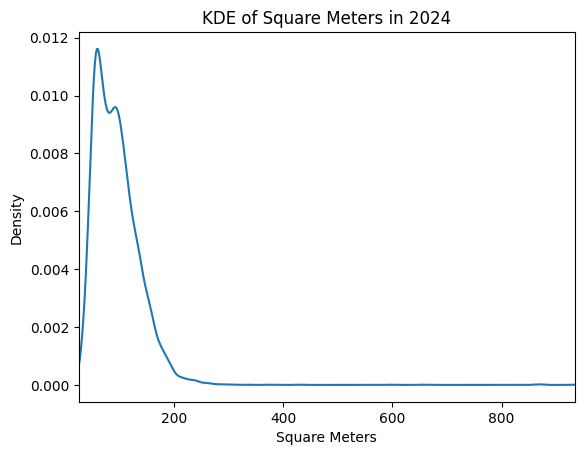

In [10]:
sqm_2024 = df[df['date'] >= '2024-01-01']['sqm']
lower, upper = sqm_2024.quantile([0, 1])
sqm_2024.plot(kind='kde')
plt.title('KDE of Square Meters in 2024')
plt.xlabel('Square Meters')
plt.ylabel('Density')
plt.xlim(lower, upper)
plt.show()

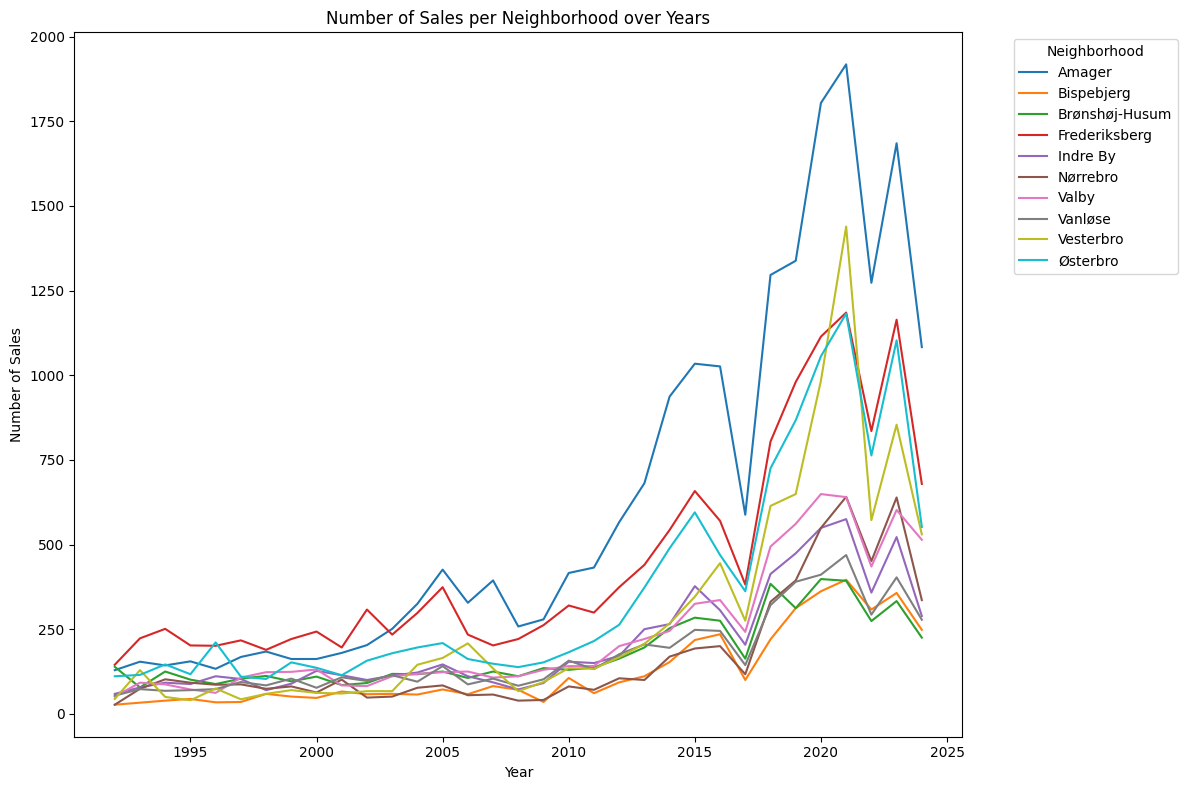

In [11]:
# Plot number of sales per neighborhood over the years
import matplotlib.pyplot as plt

# Group by year and neighborhood, count the number of sales
sales_per_year_neigh = df.groupby([df['date'].dt.year, 'neighborhood']).size().unstack()

# Plot as line chart
sales_per_year_neigh.plot(kind='line', figsize=(12, 8))
plt.title('Number of Sales per Neighborhood over Years')
plt.xlabel('Year')
plt.ylabel('Number of Sales')
plt.legend(title='Neighborhood', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 1.2 Statistics Denmark socioeconomic panel
Load five Excel cross-tables from Statistics Denmark (Statistikbanken) and reshape from wide cross-tab format to tidy long format. Run quality checks on each tidy dataset (shape, missing values, duplicate keys, value ranges).

* *HISTORICAL:*
    * *POPULATION + PERSONS OF DANISH ORIGIN VS OTHER*
    * * KKBEF2: Population by district, sex, age and ancestry (yearly data) 
    * *AMOUNT UNEMPLOYED + DEGREE OF UNEMPLOYMENT + HIGHEST EDUCATION LEVEL:*
    * * KKLEDIG6: Unemployed (yearly) by district, degree of unemployment and highest education completed (yearly data) 
    * *TYPE OF HOUSE USE, OWNERSHIP, YEAR OF COMMISSION* _?SIZE in sqm?_
    * * KBOL3: Dwellings, square meters and residents by district, ownership, year of commissioning and type of use (yearly data) 
    * *INCOME, TYPE OF INCOME*
    * * KKIND3: Income for persons (14 years +) by district, unit, sex and type of income (yearly data) 
    * *TYPE OF HOUSEHOLD, NUMBER OF CHILDREN, HOUSEHOLD SIZE*
    * * KKHUS1: Households by district, type of household, number of children in the household and household size (!!! quaterly data) 

* *FUTURE:*
    * *POPULATION PROJECTION 2026-2060*
    * * KKFR2026: Population projection 2026 by district, sex and age (yearly)

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
import re

# ============================================================
# 1) Paths
# Run from inside: mbml-cph-housing
# ============================================================
BASE = Path.cwd()

FILES = {
    "KKBEF2": BASE / "data" / "2026417213036619584456KKBEF2.xlsx",
    "KKLEDIG6": BASE / "data" / "2026417213155619584456KKLEDIG6.xlsx",
    "KKIND3": BASE / "data" / "202641721357619584456KKIND3.xlsx",
    "KKHUS1": BASE / "data" / "2026417214930619584456KKHUS1.xlsx",
    "KKFR2026": BASE / "data" / "2026417215628619584456KKFR2026.xlsx",
}

# ============================================================
# 2) File-specific layout
# These are based on the uploaded files you showed.
# ============================================================
CONFIG = {
    "KKBEF2": {
        "sheet_name": "KKBEF2",
        "header_row": 2,   # row with years
        "data_start_row": 3,
        "dim_names": ["ancestry", "age_group", "sex", "district"],
        "time_name": "year",
        "value_name": "value",
    },
    "KKLEDIG6": {
        "sheet_name": "KKLEDIG6",
        "header_row": 2,
        "data_start_row": 3,
        "dim_names": ["education", "unemployment_degree", "district"],
        "time_name": "year",
        "value_name": "value",
    },
    "KKIND3": {
        "sheet_name": "KKIND3",
        "header_row": 2,
        "data_start_row": 3,
        "dim_names": ["income_type", "sex", "unit", "district"],
        "time_name": "year",
        "value_name": "value",
    },
    "KKHUS1": {
        "sheet_name": "KKHUS1",
        "header_row": 2,   # row with quarter labels like 1998Q1
        "data_start_row": 3,
        "dim_names": ["household_size", "children_in_household", "household_type", "district"],
        "time_name": "quarter",
        "value_name": "value",
    },
    "KKFR2026": {
        "sheet_name": "KKFR2026",
        "header_row": 2,
        "data_start_row": 3,
        "dim_names": ["sex", "district", "age"],
        "time_name": "year",
        "value_name": "value",
    },
}

# ============================================================
# 3) Helpers
# ============================================================
def clean_text(x):
    """Standardize cell text while preserving real missing values."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in {"", "nan", "None", "NA", "N/A"}:
        return np.nan
    x = re.sub(r"\s+", " ", x)
    return x

def clean_district_name(x):
    """Optional cleanup for district labels."""
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = re.sub(r"^District\s*-\s*", "", x)
    return x

def parse_quarter_to_period(q):
    """
    Convert strings like 1998Q1 to pandas Period('1998Q1', freq='Q').
    If parsing fails, return original value.
    """
    if pd.isna(q):
        return np.nan
    q = str(q).strip()
    m = re.fullmatch(r"(\d{4})Q([1-4])", q)
    if m:
        year, quarter = m.groups()
        return pd.Period(f"{year}Q{quarter}", freq="Q")
    return q

def load_crosstab_excel(path, sheet_name, header_row, data_start_row, dim_names, time_name, value_name):
    """
    Read a Statistikbanken-style Excel cross table and reshape it to tidy long format.
    """
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # Clean all cells lightly
    raw = raw.applymap(clean_text)

    n_dims = len(dim_names)

    # Extract time labels from header row
    time_labels = raw.iloc[header_row, n_dims:].tolist()

    # Keep only rows that contain at least one non-missing value somewhere
    data = raw.iloc[data_start_row:, :].copy()
    data = data.dropna(how="all").reset_index(drop=True)

    # Rename columns
    data.columns = dim_names + time_labels

    # Forward-fill the dimension columns only
    data[dim_names] = data[dim_names].ffill()

    # Melt to long format
    tidy = data.melt(
        id_vars=dim_names,
        var_name=time_name,
        value_name=value_name
    )

    # Remove missing values in the measure column
    tidy[value_name] = pd.to_numeric(tidy[value_name], errors="coerce")
    tidy = tidy.dropna(subset=[value_name]).reset_index(drop=True)

    # Clean dimension values
    for col in dim_names:
        tidy[col] = tidy[col].apply(clean_text)

    # District cleanup
    if "district" in tidy.columns:
        tidy["district"] = tidy["district"].apply(clean_district_name)

    # Convert time column
    if time_name == "year":
        tidy[time_name] = pd.to_numeric(tidy[time_name], errors="coerce").astype("Int64")
    elif time_name == "quarter":
        tidy[time_name] = tidy[time_name].apply(parse_quarter_to_period)

    # Final sort
    sort_cols = [c for c in dim_names + [time_name] if c in tidy.columns]
    tidy = tidy.sort_values(sort_cols).reset_index(drop=True)

    return tidy

# ============================================================
# 4) Load all files into tidy dataframes
# ============================================================
data = {}
summary = []

for name, path in FILES.items():
    cfg = CONFIG[name]

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    _sdf = load_crosstab_excel(
        path=path,
        sheet_name=cfg["sheet_name"],
        header_row=cfg["header_row"],
        data_start_row=cfg["data_start_row"],
        dim_names=cfg["dim_names"],
        time_name=cfg["time_name"],
        value_name=cfg["value_name"],
    )

    data[name] = _sdf

    summary.append({
        "dataset": name,
        "rows": len(_sdf),
        "columns": len(_sdf.columns),
        "time_column": cfg["time_name"],
        "min_time": str(_sdf[cfg["time_name"]].min()) if len(_sdf) else None,
        "max_time": str(_sdf[cfg["time_name"]].max()) if len(_sdf) else None,
    })

# ============================================================
# 5) Create direct dataframe variables
# ============================================================
KKBEF2 = data["KKBEF2"]
KKLEDIG6 = data["KKLEDIG6"]
KKIND3 = data["KKIND3"]
KKHUS1 = data["KKHUS1"]
KKFR2026 = data["KKFR2026"]

# ============================================================
# 6) Print overview
# ============================================================
summary_df = pd.DataFrame(summary)
print("Tidy datasets loaded:")
print(summary_df)

print("\nKKBEF2 sample:")
print(KKBEF2.head())

print("\nKKLEDIG6 sample:")
print(KKLEDIG6.head())

print("\nKKIND3 sample:")
print(KKIND3.head())

print("\nKKHUS1 sample:")
print(KKHUS1.head())

print("\nKKFR2026 sample:")
print(KKFR2026.head())

# ============================================================
# 7) Optional: save cleaned versions
# ============================================================
output_dir = BASE / "data" / "cleaned"
output_dir.mkdir(parents=True, exist_ok=True)

KKBEF2.to_csv(output_dir / "KKBEF2_tidy.csv", index=False)
KKLEDIG6.to_csv(output_dir / "KKLEDIG6_tidy.csv", index=False)
KKIND3.to_csv(output_dir / "KKIND3_tidy.csv", index=False)
KKHUS1.to_csv(output_dir / "KKHUS1_tidy.csv", index=False)
KKFR2026.to_csv(output_dir / "KKFR2026_tidy.csv", index=False)

print(f"\nCleaned CSV files saved to: {output_dir}")

/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_21516/105591925.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_21516/105591925.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_21516/105591925.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_21516/105591925.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_21516/105591925.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)


Tidy datasets loaded:
    dataset   rows  columns time_column min_time max_time
0    KKBEF2  23194        6        year     1986     2025
1  KKLEDIG6   4800        5        year     2008     2023
2    KKIND3  11400        6        year     1987     2024
3    KKHUS1  76800        6     quarter   1998Q1   2024Q4
4  KKFR2026  70000        5        year     2026     2060

KKBEF2 sample:
                            ancestry   age_group  sex     district  year  \
0  Descendants of non-western origin  0-10 years  Men  Amager Vest  1986   
1  Descendants of non-western origin  0-10 years  Men  Amager Vest  1987   
2  Descendants of non-western origin  0-10 years  Men  Amager Vest  1988   
3  Descendants of non-western origin  0-10 years  Men  Amager Vest  1989   
4  Descendants of non-western origin  0-10 years  Men  Amager Vest  1990   

   value  
0  109.0  
1  136.0  
2  163.0  
3  168.0  
4  189.0  

KKLEDIG6 sample:
                           education unemployment_degree     district  ye

In [13]:
import pandas as pd

# Assumes these already exist from your load script:
# data, KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026

datasets = {
    "KKBEF2": KKBEF2,
    "KKLEDIG6": KKLEDIG6,
    "KKIND3": KKIND3,
    "KKHUS1": KKHUS1,
    "KKFR2026": KKFR2026,
}

for name, _sdf in datasets.items():
    print("=" * 80)
    print(f"{name}")
    print("=" * 80)

    print("\nShape:")
    print(_sdf.shape)

    print("\nColumns:")
    print(_sdf.columns.tolist())

    print("\nDtypes:")
    print(_sdf.dtypes)

    print("\nMissing values per column:")
    print(_sdf.isna().sum())

    print("\nExact duplicate rows:")
    print(_sdf.duplicated().sum())

    # Identify value and time columns
    value_col = "value"
    time_col = "quarter" if "quarter" in _sdf.columns else "year"

    # Dimension columns = everything except time and value
    dim_cols = [c for c in _sdf.columns if c not in [time_col, value_col]]

    print("\nDimension columns:")
    print(dim_cols)

    print("\nNumber of duplicated keys (same dimensions + same time):")
    print(_sdf.duplicated(subset=dim_cols + [time_col]).sum())

    print("\nValue summary:")
    print(_sdf[value_col].describe())

    print("\nNegative values count:")
    print((_sdf[value_col] < 0).sum())

    print("\nSample rows:")
    print(_sdf.head(10))

    print("\nUnique values per dimension column (first 15 shown):")
    for col in dim_cols:
        uniques = _sdf[col].dropna().unique()
        print(f"\n- {col}: {len(uniques)} unique")
        print(list(uniques[:15]))

    print("\nTime column summary:")
    print("Type:", _sdf[time_col].dtype)
    print("Min:", _sdf[time_col].min())
    print("Max:", _sdf[time_col].max())

    # Check if every key-time combination appears only once
    group_sizes = _sdf.groupby(dim_cols + [time_col]).size()
    bad_groups = group_sizes[group_sizes > 1]

    print("\nNumber of key-time combinations appearing more than once:")
    print(len(bad_groups))

    if len(bad_groups) > 0:
        print("\nFirst 10 duplicated key-time combinations:")
        print(bad_groups.head(10))

    print("\n")

KKBEF2

Shape:
(23194, 6)

Columns:
['ancestry', 'age_group', 'sex', 'district', 'year', 'value']

Dtypes:
ancestry      object
age_group     object
sex           object
district      object
year           Int64
value        float64
dtype: object

Missing values per column:
ancestry     0
age_group    0
sex          0
district     0
year         0
value        0
dtype: int64

Exact duplicate rows:
0

Dimension columns:
['ancestry', 'age_group', 'sex', 'district']

Number of duplicated keys (same dimensions + same time):
0

Value summary:
count    23194.000000
mean       906.619298
std       1484.900458
min          0.000000
25%         49.000000
50%        219.000000
75%       1096.000000
max      11420.000000
Name: value, dtype: float64

Negative values count:
0

Sample rows:
                            ancestry   age_group  sex     district  year  \
0  Descendants of non-western origin  0-10 years  Men  Amager Vest  1986   
1  Descendants of non-western origin  0-10 years  Men  Amage

In [14]:
for name, _sdf in datasets.items():
    time_col = "quarter" if "quarter" in _sdf.columns else "year"
    print(name, "->", _sdf[time_col].isna().sum(), "missing time values")

KKBEF2 -> 0 missing time values
KKLEDIG6 -> 0 missing time values
KKIND3 -> 0 missing time values
KKHUS1 -> 0 missing time values
KKFR2026 -> 0 missing time values


### 1.3 Build historical panel
Pivot each tidy dataset to wide format (district × year) and outer-merge into a single historical panel (1986–2025). Quarterly KKHUS1 household data is averaged to annual frequency before pivoting. The future population projections (KKFR2026, 2026–2060) are kept as a separate panel for use in Phase 6 forecasting.

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# Assumes these already exist from your tidy import script:
# KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026
# ============================================================

# ============================================================
# 1) Helpers
# ============================================================
def safe_slug(x):
    x = str(x).strip().lower()
    x = x.replace("&", "and")
    x = x.replace("%", "pct")
    x = x.replace("/", "_")
    x = x.replace("-", "_")
    x = x.replace(",", "")
    x = x.replace(".", "")
    x = x.replace("(", "")
    x = x.replace(")", "")
    x = x.replace(":", "")
    x = x.replace("'", "")
    x = x.replace('"', "")
    x = "_".join(x.split())
    while "__" in x:
        x = x.replace("__", "_")
    return x

def flatten_columns(columns):
    flat = []
    for col in columns:
        if isinstance(col, tuple):
            parts = [safe_slug(c) for c in col if c not in [None, "", "nan"]]
            flat.append("_".join(parts))
        else:
            flat.append(safe_slug(col))
    return flat

def make_wide(_sdf, id_cols, category_cols, value_col, prefix):
    """
    Converts tidy long _sdf into district-year wide format.
    """
    out = _sdf.copy()

    # Ensure clean types
    out = out.dropna(subset=id_cols + category_cols + [value_col]).copy()

    # Pivot to wide
    wide = out.pivot_table(
        index=id_cols,
        columns=category_cols,
        values=value_col,
        aggfunc="sum"
    ).reset_index()

    # Flatten multiindex columns
    wide.columns = id_cols + [
        f"{prefix}_" + "_".join([safe_slug(x) for x in col]) if isinstance(col, tuple) else f"{prefix}_{safe_slug(col)}"
        for col in wide.columns[len(id_cols):]
    ]

    return wide

# ============================================================
# 2) Standardize district/year formats
# ============================================================
KKBEF2 = KKBEF2.copy()
KKLEDIG6 = KKLEDIG6.copy()
KKIND3 = KKIND3.copy()
KKHUS1 = KKHUS1.copy()
KKFR2026 = KKFR2026.copy()

for _sdf in [KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026]:
    if "district" in _sdf.columns:
        _sdf["district"] = _sdf["district"].astype(str).str.strip()

if "year" in KKBEF2.columns:
    KKBEF2["year"] = pd.to_numeric(KKBEF2["year"], errors="coerce").astype("Int64")
if "year" in KKLEDIG6.columns:
    KKLEDIG6["year"] = pd.to_numeric(KKLEDIG6["year"], errors="coerce").astype("Int64")
if "year" in KKIND3.columns:
    KKIND3["year"] = pd.to_numeric(KKIND3["year"], errors="coerce").astype("Int64")
if "year" in KKFR2026.columns:
    KKFR2026["year"] = pd.to_numeric(KKFR2026["year"], errors="coerce").astype("Int64")

# Convert quarter -> year for housing
if "quarter" in KKHUS1.columns:
    if str(KKHUS1["quarter"].dtype) == "period[Q-DEC]":
        KKHUS1["year"] = KKHUS1["quarter"].dt.year.astype("Int64")
    else:
        KKHUS1["year"] = (
            KKHUS1["quarter"]
            .astype(str)
            .str.extract(r"(\d{4})", expand=False)
            .pipe(pd.to_numeric, errors="coerce")
            .astype("Int64")
        )

# ============================================================
# 3) Aggregate quarterly housing to annual mean
# ============================================================
KKHUS1_yearly = (
    KKHUS1
    .groupby(["household_size", "children_in_household", "household_type", "district", "year"], as_index=False)["value"]
    .mean()
)

# ============================================================
# 4) Pivot each dataset to district-year wide format
# ============================================================
KKBEF2_wide = make_wide(
    _sdf=KKBEF2,
    id_cols=["district", "year"],
    category_cols=["ancestry", "age_group", "sex"],
    value_col="value",
    prefix="pop"
)

KKLEDIG6_wide = make_wide(
    _sdf=KKLEDIG6,
    id_cols=["district", "year"],
    category_cols=["education", "unemployment_degree"],
    value_col="value",
    prefix="unemp"
)

KKIND3_wide = make_wide(
    _sdf=KKIND3,
    id_cols=["district", "year"],
    category_cols=["income_type", "sex", "unit"],
    value_col="value",
    prefix="income"
)

KKHUS1_wide = make_wide(
    _sdf=KKHUS1_yearly,
    id_cols=["district", "year"],
    category_cols=["household_size", "children_in_household", "household_type"],
    value_col="value",
    prefix="housing"
)

KKFR2026_wide = make_wide(
    _sdf=KKFR2026,
    id_cols=["district", "year"],
    category_cols=["sex", "age"],
    value_col="value",
    prefix="proj_pop"
)

# ============================================================
# 5) Merge historical datasets
# Use outer merge to keep all district-year combinations
# ============================================================
historical_panel = KKBEF2_wide.merge(
    KKLEDIG6_wide, on=["district", "year"], how="outer"
).merge(
    KKIND3_wide, on=["district", "year"], how="outer"
).merge(
    KKHUS1_wide, on=["district", "year"], how="outer"
)

historical_panel = historical_panel.sort_values(["district", "year"]).reset_index(drop=True)

# ============================================================
# 6) Keep future population projections separate
# Since only KKFR2026 covers future years
# ============================================================
future_population_panel = KKFR2026_wide.sort_values(["district", "year"]).reset_index(drop=True)

# ============================================================
# 7) Optional combined panel
# This appends future projections to historical data structure
# Most future columns will be NaN except projected population
# ============================================================
combined_panel = historical_panel.merge(
    future_population_panel, on=["district", "year"], how="outer"
).sort_values(["district", "year"]).reset_index(drop=True)

# ============================================================
# 8) Diagnostics
# ============================================================
print("=" * 80)
print("HISTORICAL PANEL")
print("=" * 80)
print("Shape:", historical_panel.shape)
print("Years:", historical_panel["year"].min(), "to", historical_panel["year"].max())
print("Districts:", historical_panel["district"].nunique())
print("Duplicated district-year rows:", historical_panel.duplicated(subset=["district", "year"]).sum())
print(historical_panel.head())

print("\n" + "=" * 80)
print("FUTURE POPULATION PANEL")
print("=" * 80)
print("Shape:", future_population_panel.shape)
print("Years:", future_population_panel["year"].min(), "to", future_population_panel["year"].max())
print("Districts:", future_population_panel["district"].nunique())
print("Duplicated district-year rows:", future_population_panel.duplicated(subset=["district", "year"]).sum())
print(future_population_panel.head())

print("\n" + "=" * 80)
print("COMBINED PANEL")
print("=" * 80)
print("Shape:", combined_panel.shape)
print("Years:", combined_panel["year"].min(), "to", combined_panel["year"].max())
print("Districts:", combined_panel["district"].nunique())
print("Duplicated district-year rows:", combined_panel.duplicated(subset=["district", "year"]).sum())
print(combined_panel.head())

# ============================================================
# 9) Save outputs
# ============================================================
BASE = Path.cwd()
output_dir = BASE / "data" / "cleaned"
output_dir.mkdir(parents=True, exist_ok=True)

historical_panel.to_csv(output_dir / "historical_panel_merged.csv", index=False)
future_population_panel.to_csv(output_dir / "future_population_panel.csv", index=False)
combined_panel.to_csv(output_dir / "combined_panel_with_future_population.csv", index=False)

print(f"\nSaved to: {output_dir}")
print("- historical_panel_merged.csv")
print("- future_population_panel.csv")
print("- combined_panel_with_future_population.csv")

HISTORICAL PANEL
Shape: (400, 212)
Years: 1986 to 2025
Districts: 10
Duplicated district-year rows: 0
      district  year  pop_descendants_of_non_western_origin_0_10_years_men  \
0  Amager Vest  1986                                              109.0      
1  Amager Vest  1987                                              136.0      
2  Amager Vest  1988                                              163.0      
3  Amager Vest  1989                                              168.0      
4  Amager Vest  1990                                              189.0      

   pop_descendants_of_non_western_origin_0_10_years_women  \
0                                              129.0        
1                                              143.0        
2                                              154.0        
3                                              182.0        
4                                              185.0        

   pop_descendants_of_non_western_origin_10_19_years_men  \
0 

## Phase 2 - Feature Engineering
Goal - Transform raw inputs into the district × year panel that feeds the Pyro model

### 2.1 Aggregate housing prices to district-year level

The housing dataset contains one row per *transaction*. The Bayesian model needs one representative
price signal per *district per year*. The cell below collapses ~91,000 regular-sale transactions
into a compact panel.

### Section 2.1: Target Variable Design (Median Log SQM Price)

In this phase, we aggregate raw transaction data into a robust target variable suitable for Bayesian modeling. The following design choices ground our approach:

* **Price per Square Meter ($sqm\_price$):** Normalizes for property size, allowing the model to compare the intrinsic value of different locations regardless of whether they feature small studios or large houses.
* **Median Aggregation:** We use the median rather than the mean to provide robustness against extreme outliers and luxury sales, ensuring the target reflects the "typical" market value of a district.
* **Log-Transformation ($log\_sqm\_price$):** This choice satisfies the **Gaussian likelihood** assumption of our observation model ($y_{dt} \sim Normal(\mu, \sigma)$). It also transforms skewed price distributions into more symmetric ones and improves numerical stability during inference.
* **Heteroskedastic Noise ($\sigma_{obs}$):** We calculate the standard deviation of log-prices (`std_log_sqm_price`) for each district-year. In the Pyro model, this is treated as **observed noise**, allowing the model to weigh consistent market years more heavily than highly volatile ones.

**Design choices:**

| Choice | Reason |
|---|---|
| **Regular sales only** | Family sales (`family_sale`) are transfers between relatives at below-market prices — they reflect family agreements, not the market. Auctions and other sale types have different dynamics. Including them would bias the price signal downward and add noise. |
| **`log(sqm_price)` before aggregating** | Housing prices are right-skewed and span roughly 5× across districts. The log transformation makes the distribution approximately Gaussian and matches the **log-normal likelihood** the Pyro model will use. `median(log(x)) = log(median(x))` by monotonicity of log, so the two orderings are equivalent for the median. |
| **Median, not mean** | The median is robust to the occasional extreme transaction (luxury penthouses, distressed sales) that would pull the mean upward. |
| **`std_log_sqm_price` (within-cell std)** | Measures how *consistent* prices are within a district-year cell. A cell with high variance (few transactions or mixed property types) carries more measurement uncertainty. In Pyro this becomes **σ_obs** — the observation noise, giving data-informed weights: cells with consistent prices constrain the posterior more tightly than cells with scattered prices. |
| **`n_transactions`** | Sample size per cell. Small-n cells (< 10 transactions) produce unreliable medians and inflated standard deviations. Flagged in the diagnostics below. |
| **`pct_change_median`** | Median percentage change between listing price and final purchase price. A proxy for *market tightness*: negative = buyer's market (sellers discount), positive = seller's market (bidding wars). Useful as a model covariate, but may correlate with the interest rate already

In [16]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

Shape: (330, 10)

Year coverage per district:
                 min   max  count
district                         
Amager          1992  2024     33
Bispebjerg      1992  2024     33
Brønshøj-Husum  1992  2024     33
Frederiksberg   1992  2024     33
Indre By        1992  2024     33
Nørrebro        1992  2024     33
Valby           1992  2024     33
Vanløse         1992  2024     33
Vesterbro       1992  2024     33
Østerbro        1992  2024     33

District-years with fewer than 10 transactions:
Empty DataFrame
Columns: [district, year, median_log_sqm_price, mean_log_sqm_price, std_log_sqm_price, n_transactions, median_sqm, median_purchase_price, pct_change_median, sem_log_sqm_price]
Index: []


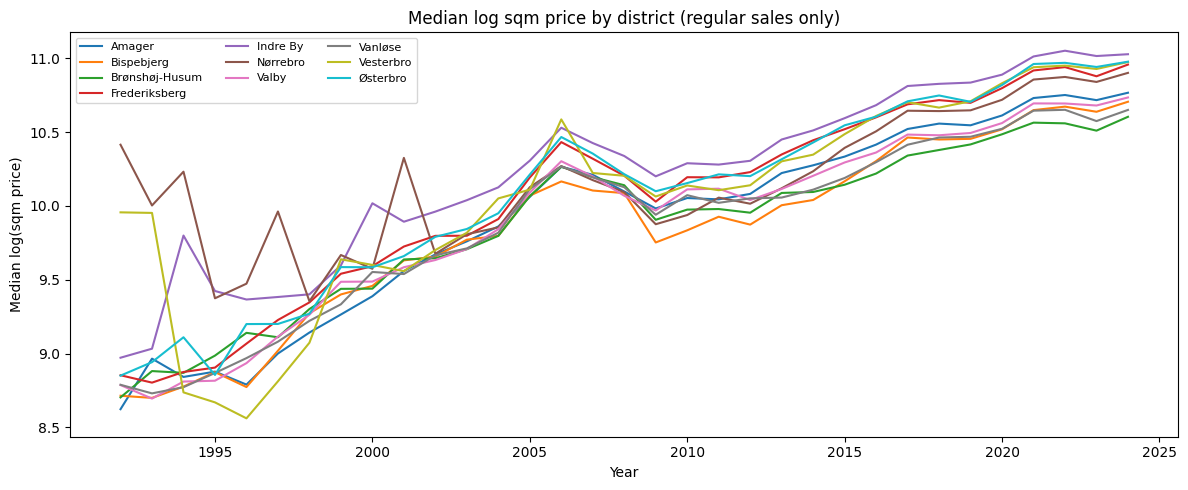


Saved: data/cleaned/housing_agg_district_year.csv


In [17]:
# Adding a filter for regular sales only, mapped district, and valid sqm_price
mask = (
    df['neighborhood'].notna() & 
    (df['sales_type'] == 'regular_sale') &
    df['sqm_price'].notna() &
    (df['sqm_price'] > 0)
) 

# Apply the filter to the dataframe
df_filtered = df[mask].copy()

df_filtered['year'] = df_filtered['date'].dt.year
df_filtered['log_sqm_price'] = np.log(df_filtered['sqm_price'])

# Aggregate to district × year level
housing_agg = (
    df_filtered.groupby(['neighborhood', 'year'])
    .agg(
        median_log_sqm_price   = ('log_sqm_price', 'median'),
        mean_log_sqm_price     = ('log_sqm_price', 'mean'),
        std_log_sqm_price      = ('log_sqm_price', 'std'),
        n_transactions         = ('sqm_price', 'count'),
        median_sqm             = ('sqm', 'median'),
        median_purchase_price  = ('purchase_price', 'median'),
        pct_change_median      = ('%_change_between_offer_and_purchase', 'median')
    )
    .reset_index()
    .rename(columns={'neighborhood': 'district'})
)

# Standard Error of the Median for each district-year cell.
# The asymptotic constant 1.253 converts the sample std to an estimate
# of the sampling uncertainty of the median (vs the mean, which uses 1/sqrt(N)).
# This is used as sigma_obs in the Pyro model so that a district-year with
# 10 transactions carries less weight than one with 1000.
housing_agg['sem_log_sqm_price'] = (
    1.253 * housing_agg['std_log_sqm_price'] / np.sqrt(housing_agg['n_transactions'])
)

print('Shape:', housing_agg.shape)
print('\nYear coverage per district:')
print(housing_agg.groupby('district')['year'].agg(['min', 'max', 'count']))
print('\nDistrict-years with fewer than 10 transactions:')
print(housing_agg[housing_agg['n_transactions'] < 10])

fig, ax = plt.subplots(figsize=(12, 5))
for dist, grp in housing_agg.groupby('district'):
    ax.plot(grp['year'], grp['median_log_sqm_price'], label=dist, linewidth=1.5)
ax.set_title('Median log sqm price by district (regular sales only)')
ax.set_xlabel('Year')
ax.set_ylabel('Median log(sqm price)')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

housing_agg.to_csv('data/cleaned/housing_agg_district_year.csv', index=False)
print('\nSaved: data/cleaned/housing_agg_district_year.csv')

### 2.2 Align district names and collapse Amager sub-districts

Before the two datasets can be joined, their district names must match exactly.
The housing dataset uses simplified informal names (from the zip-code mapping);
Statistics Denmark uses official administrative names.

Three issues to resolve:

1. **`Vesterbro` → `Vesterbro/Kongens Enghave`** — the full administrative name includes Kongens Enghave
2. **Drop `Frederiksberg`** — Frederiksberg is an independent municipality
3. **Collapse `Amager Øst` + `Amager Vest` → `Amager`** — zip code 2300 spans both sub-districts. We aggregate the two Statistics Denmark rows into one by summing. Summing is correct because all panel columns are count-type totals (population headcounts, unemployment counts, income totals in DKK 1,000). Per-capita derived features (e.g. income per capita) will be computed as `sum(income) / sum(population)` in Phase 2.5, which gives the correct combined-district average.

In [18]:
# Load the historical panel (socioeconomic features from Statistikbanken) that we created in Phase 1 
historical_panel = pd.read_csv('data/cleaned/historical_panel_merged.csv')

print("Aggrigated housing data districts:   ", sorted(housing_agg['district'].unique()))
print("Historical socioeconomic panel districts: ", sorted(historical_panel['district'].unique()))

# -- Part 1: rename districts in housing_agg to match historical_panel
# Vesterbro → matches panel name; Amager stays as-is (we fix the panel side)
housing_agg['district'] = housing_agg['district'].replace(
    {'Vesterbro': 'Vesterbro/Kongens Enghave'}
)
# Frederiksberg is a separate municipality — not in Statistics Denmark tables -> drop it from housing_agg
housing_agg = housing_agg[housing_agg['district'] != 'Frederiksberg'].copy() 

# -- Part 2: sum Amager Øst & Vest in the panel to match the housing data (which has them combined as Amager)
#  # zip 2300 covers both sub-districts, so housing transactions cannot be split)
# All panel columns are count-type → sum is the correct aggregation.
amager_rows = historical_panel[historical_panel['district'].isin(['Amager Øst', 'Amager Vest'])]
amager_combined = (
    amager_rows
    .drop(columns=['district']) # drop old district column
    .groupby('year', as_index=False) # group by year to sum the two sub-districts
    .sum(numeric_only=True) # sum only numeric columns, keep 'year' as-is
)
amager_combined.insert(0, 'district', 'Amager') # add new district column with combined name

# Drop old rows and append combined Amager
historical_panel = pd.concat([
    historical_panel[~historical_panel['district'].isin(['Amager Øst', 'Amager Vest'])],
    amager_combined
], ignore_index=True).sort_values(['district', 'year']).reset_index(drop=True)

# -- Verify final district alignment
agg_dists = set(housing_agg['district'].unique())
panel_dists = set(historical_panel['district'].unique())
unmatched = agg_dists.symmetric_difference(panel_dists)

if unmatched:
    print("\nWarning: Unmatched districts after cleaning:", unmatched)
else:
    print("\nSuccess: Districts are aligned between datasets.")

# Save the cleaned historical panel for modeling
housing_agg.to_csv('data/cleaned/housing_agg_district_year.csv', index=False)
historical_panel.to_csv('data/cleaned/historical_panel_merged_aligned.csv', index=False)
print("\nSaved: housing_agg_district_year.csv  (aligned)")
print("Saved: historical_panel_merged_aligned.csv")

Aggrigated housing data districts:    ['Amager', 'Bispebjerg', 'Brønshøj-Husum', 'Frederiksberg', 'Indre By', 'Nørrebro', 'Valby', 'Vanløse', 'Vesterbro', 'Østerbro']
Historical socioeconomic panel districts:  ['Amager Vest', 'Amager Øst', 'Bispebjerg', 'Brønshøj-Husum', 'Indre By', 'Nørrebro', 'Valby', 'Vanløse', 'Vesterbro/Kongens Enghave', 'Østerbro']

Success: Districts are aligned between datasets.

Saved: housing_agg_district_year.csv  (aligned)
Saved: historical_panel_merged_aligned.csv


### 2.3 Join raw transactions (`df`) with `historical_panel`

Left-join **each sale** in `df` to the **district–year** socioeconomic panel on `(district, year)` (same district naming as `housing_agg`: `neighborhood` → `district`, Vesterbro rename). Rows without a mappable district are dropped before the join.

**Two outputs:**

| DataFrame | Years | Purpose |
|-----------|-------|---------|
| `model_panel_ungrouped` | All years present in `df` that match keys in `historical_panel` | Full horizon; pre-2008 rows can have missing unemployment breakdowns in the panel (same issue as `model_panel_full`). |
| `model_panel_ungrouped_restricted` | **year ≥ 2008** | Matches the **KKLEDIG6** availability window — comparable spirit to `model_panel_restricted` for analyses that need complete unemployment covariates. |


In [19]:
_tx = df.copy()
_tx["year"] = _tx["date"].dt.year
_tx["district"] = _tx["neighborhood"].replace(
    {"Vesterbro": "Vesterbro/Kongens Enghave"}
)
_tx = _tx.dropna(subset=["neighborhood", "district", "year"], how="any")
_tx = _tx.loc[_tx["district"].astype(str).str.strip().ne("")].copy()

_hp = historical_panel.set_index(["district", "year"])

model_panel_ungrouped = (
    _tx.set_index(["district", "year"])
    .join(_hp, how="left")
    .reset_index()
)

model_panel_ungrouped_restricted = model_panel_ungrouped.loc[
    model_panel_ungrouped["year"] >= 2008
].copy()

print("model_panel_ungrouped:", model_panel_ungrouped.shape)
print("model_panel_ungrouped_restricted:", model_panel_ungrouped_restricted.shape)


model_panel_ungrouped: (91553, 227)
model_panel_ungrouped_restricted: (72176, 227)


## Checking whether "sqm_price" in dataframe model_panel_ungrouped_restricted follows a normal distribution: 

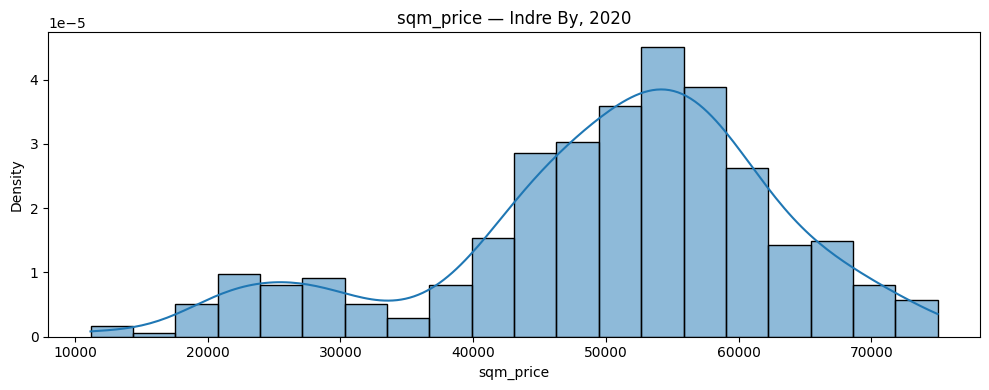

n = 549


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

district = "Indre By"   # change
year = 2020             # change

sub = model_panel_ungrouped_restricted[
    (model_panel_ungrouped_restricted["district"] == district)
    & (model_panel_ungrouped_restricted["year"] == year)
]

x = sub["sqm_price"].dropna()
if x.empty:
    raise ValueError(f"No rows for district={district!r}, year={year}")

fig, ax = plt.subplots(figsize=(10, 4))

sns.histplot(x, kde=True, stat="density", ax=ax)
ax.set_title(f"sqm_price — {district}, {year}")

plt.tight_layout()
plt.show()

print("n =", len(x))

In [21]:
model_panel_ungrouped_restricted["district"]

0        Vesterbro/Kongens Enghave
1                    Frederiksberg
2                   Brønshøj-Husum
3                           Amager
4                           Amager
                   ...            
72171                Frederiksberg
72172                       Amager
72173                       Amager
72174    Vesterbro/Kongens Enghave
72175                Frederiksberg
Name: district, Length: 72176, dtype: object

## Mixture model 

### 2.4 Join housing aggregates with the socioeconomic panel

Merge the district-year housing aggregates with the Statistics Denmark historical panel
on the composite key `(district, year)` using an **inner join** — only district-years that
appear in *both* datasets are kept.

**Two output versions are produced:**

| Version | Years | Rows | Purpose |
|---|---|---|---|
| `model_panel_full` | all available (~1992–2024) | ~297 | Reference; some columns are NaN before 2008 |
| `model_panel_restricted` | 2008–2024 | ~153 | **Used for Pyro model fitting** — all covariate groups complete |

The 2008 cutoff is driven by KKLEDIG6 (unemployment by education level), which Statistics Denmark
only provides from 2008 onward.

**IF WE WANT TO INCLUDE A LONGER TIME-FRAME -> WE CAN TAKE UNEMPLOYMENT OUT**

Modeling panel shape: (297, 220)

Modeling panel year coverage per district:
                            min   max  count
district                                    
Amager                     1992  2024     33
Bispebjerg                 1992  2024     33
Brønshøj-Husum             1992  2024     33
Indre By                   1992  2024     33
Nørrebro                   1992  2024     33
Valby                      1992  2024     33
Vanløse                    1992  2024     33
Vesterbro/Kongens Enghave  1992  2024     33
Østerbro                   1992  2024     33

Nulls in key columns:
district                0
year                    0
median_log_sqm_price    0
n_transactions          0
dtype: int64


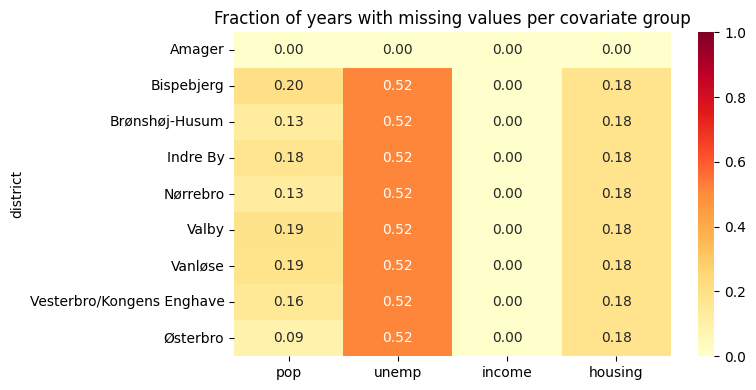


Full panel:        297 rows, years 1992–2024
Restricted panel:  153 rows, years 2008–2024


In [22]:
# Creating combined dataset for modelling 
# -- Inner join on district * year to keep only rows where we have both housing and socioeconomic data -- 
model_panel = housing_agg.merge(historical_panel, on=['district', 'year'], how='inner')

# Check the shape and coverage of the final modeling panel
print("Modeling panel shape:", model_panel.shape)
print("\nModeling panel year coverage per district:")
print(model_panel.groupby('district')['year'].agg(['min', 'max', 'count']))
print("\nNulls in key columns:")
print(model_panel[['district', 'year', 'median_log_sqm_price', 'n_transactions']].isnull().sum())

# Missing values by covariate group 
#   (we want to check if missingness is concentrated in certain districts or years, which could bias our model)
prefixes = ['pop', 'unemp', 'income', 'housing']
covariate_cols = [col for col in model_panel.columns if any(col.startswith(p) for p in prefixes)]

miss_frac = model_panel.groupby('district')[covariate_cols].apply(lambda df: df.isnull().mean())

miss_by_prefix = {}
for pfx in prefixes:
    cols = [col for col in covariate_cols if col.startswith(pfx)]
    if cols:
        miss_by_prefix[pfx.rstrip('_')] = miss_frac[cols].mean(axis=1)

miss_summary = pd.DataFrame(miss_by_prefix)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(miss_summary, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
ax.set_title('Fraction of years with missing values per covariate group')
plt.tight_layout()
plt.show()

# ── Two panel versions ────────────────────────────────────────────────────────
# Full panel: all available years (unemp_ columns will be NaN before 2008)
# Restricted: year >= 2008 — all covariate groups complete, used for model fitting
model_panel_full       = model_panel.copy()
model_panel_restricted = model_panel[model_panel['year'] >= 2008].copy()

model_panel_full.to_csv('data/cleaned/model_panel_full.csv', index=False)
model_panel_restricted.to_csv('data/cleaned/model_panel_restricted.csv', index=False)

print(f"\nFull panel:       {model_panel_full.shape[0]:4d} rows, "
      f"years {model_panel_full['year'].min()}–{model_panel_full['year'].max()}")
print(f"Restricted panel: {model_panel_restricted.shape[0]:4d} rows, "
      f"years 2008–{model_panel_restricted['year'].max()}")

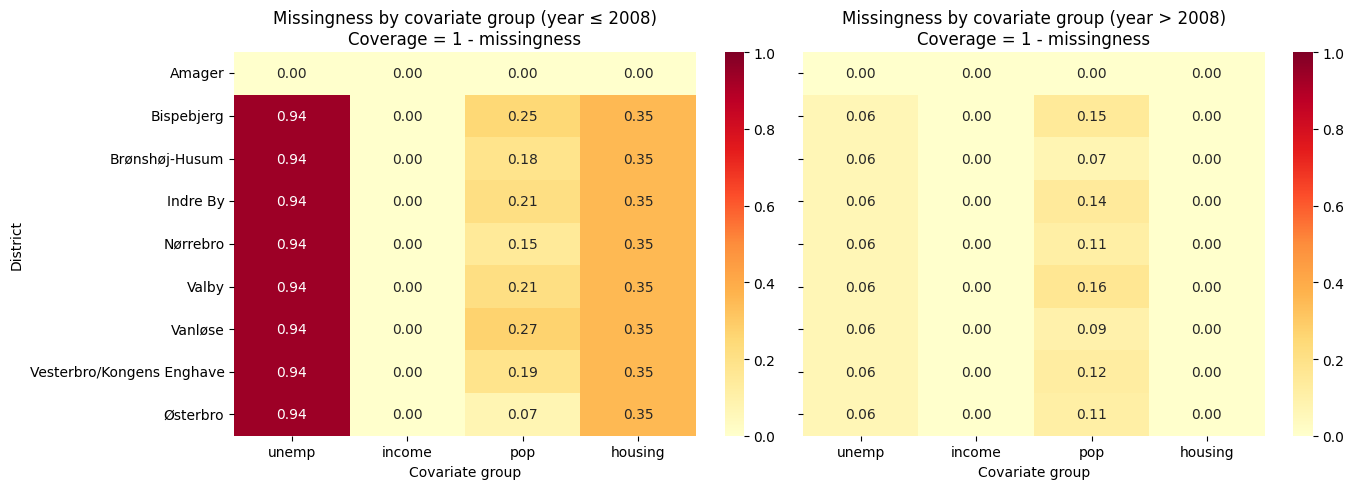

In [23]:
panel = model_panel_full.copy() if "model_panel_full" in globals() else model_panel.copy()

prefixes = ['unemp_', 'income_', 'pop_', 'housing_']
covariate_cols = [c for c in panel.columns if any(c.startswith(p) for p in prefixes)]

def missing_by_group(df_period):
    miss_frac = df_period.groupby('district')[covariate_cols].apply(lambda g: g.isnull().mean())
    out = {}
    for pfx in prefixes:
        cols = [c for c in covariate_cols if c.startswith(pfx)]
        if cols:
            out[pfx.rstrip('_')] = miss_frac[cols].mean(axis=1)
    return pd.DataFrame(out).sort_index()

miss_pre  = missing_by_group(panel[panel['year'] <= 2008])
miss_post = missing_by_group(panel[panel['year'] > 2008])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.heatmap(miss_pre, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Missingness by covariate group (year ≤ 2008)\nCoverage = 1 - missingness')
axes[0].set_xlabel('Covariate group')
axes[0].set_ylabel('District')

sns.heatmap(miss_post, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Missingness by covariate group (year > 2008)\nCoverage = 1 - missingness')
axes[1].set_xlabel('Covariate group')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

AI comments: 
- `unemp` row **fully red** before 2008 and white after
- `pop`, `income`, `housing` rows should be **white** (no missing values) for all years after ~1992, confirming those covariates are complete in the restricted panel.
- If any district shows unexpected missing values in `pop` or `income`, investigate whether that district was added to Statistics Denmark's reporting later.

**After this cell, `model_panel_restricted` is ready for Phase 2.5 (covariate reduction).**
The ~200 wide columns will be collapsed to 5–8 interpretable features:
total population, share of non-Danish origin, median disposable income per capita,
unemployment rate, and average household size.


Comments

- test if features are actually indpendent from each other for the Pyro PGM

### 2.5 Reduce covariates to 5-8 summary features
**Why is this necessary?** 

Curse of Dimensionality & Multicollinearity: Currently have around 200 columns (e.g., population counts broken down by every 10-year age bracket and gender. We reduce the ~200 wide columns into 5-8 meaningful, standardized summary features to ensure our Pyro model remains interpretable and computationally stable.

**Design choices**

| Feature | Derivation / Source | Design Rationale & Logic |
| :--- | :--- | :--- |
| **`log_total_population`** | Natural log of the sum of all `pop_*` columns (KKBEF2) | Population is used as the base for **per-capita normalization**. We log it because the relationship between district size and price is multiplicative, not additive — doubling the population does not double the price level linearly. Log linearizes this effect and compresses the 5–10× range across CPH districts, matching the log-normal structure of the target variable. The log is equivalent to converting a size effect into a *relative* one: $\Delta \log(pop)$ is a percentage change in population, which is the economically meaningful unit. |
| **`share_non_danish`** | (Sum of non-Danish `pop_*` columns) / `total_pop` | **Rate transformation** that captures demographic composition as a latent indicator of district attractiveness and market segmentation. |
| **`log_income_per_capita`** | (Sum of disposable income / `total_pop`), then take natural log | **Normalization** removes size bias; **Log transformation** linearizes the multiplicative price–income relationship ($\log(Price) \propto \beta \cdot \log(Income)$) and handles the right-skewness of income data. |
| **`unemployment_rate`** | FTE-weighted unemployed / working-age population (ages 20–60+) | **Rate transformation** used to capture local economic distress. Working-age population is defined as ages 20–59 **plus the 60+ bracket** (Danish retirement age is ~67), giving a more accurate denominator than stopping at 59. |
| **`avg_household_size`** | Weighted average of household size counts / total households | Distinguishes between **"student/single"** areas and **"family"** areas, which helps the model identify different housing demand profiles. Note: Statistics Denmark (KKHUS1) caps household size at 5 persons — 6+ person households are not separately reported, so 5 is the ceiling available in the data. |
| **`year_std`** | Standardized linear time covariate: `(year - mean) / std` | Controls for **general market trends** (inflation/global demand) in a way that is numerically stable and compatible with future forecasting. `year_std` is already a z-score by construction (mean ≈ 0, std = 1), so it is **excluded from the StandardScaler pass** — re-standardizing an already-standardized variable would produce a near-identity transformation and is redundant. |
| **Standardization (Z-score)** | Applied to all features *except* `year_std` using `StandardScaler` | Crucial for **Prior Alignment**; it allows for a consistent prior (e.g., $Normal(0, 0.5)$) regardless of the original units of the feature. |

**Rationale for Log Transformations on Population and Income**

Both `log_total_population` and `log_income_per_capita` apply the same two-step logic: **normalize to per-capita or relative scale**, then **log-transform**. The shared theoretical foundation is:

**Log Income per Capita:**
* **Normalization (Per Capita):** Raw income data represents district-wide totals. Without dividing by `total_pop`, larger districts appear artificially "wealthier" due to population volume, not individual prosperity.
* **Linearizing the Relationship (Log):** Income–price relationships are multiplicative — people allocate a *percentage* of income to housing. Log transforms this into a linear effect: $\log(Price) \propto \beta \cdot \log(Income)$, giving $\beta$ an **elasticity** interpretation (a 1% rise in income → β% rise in price).
* **Handling Skewness:** Income is right-skewed; log compresses extreme values toward a Gaussian shape, which is required by the Normal likelihood $y_{dt} \sim Normal(\mu_{dt}, \sigma)$.

**Log Total Population:**
* **Why not raw count?** CPH district populations range roughly 5–10× from smallest to largest. A raw count used as a covariate implies that each additional resident has the same marginal price effect regardless of whether the district has 20,000 or 100,000 people — implausible.
* **Log linearizes the size effect:** $\log(pop)$ means a 1-unit increase in the feature corresponds to a ~2.7× increase in population (i.e., a constant *proportional* change). This matches how urban density and agglomeration effects work in the housing literature.
* **Consistency with the target:** The target is $\log(sqm\_price)$, which is already on a log scale. Regressing $\log(price)$ on $\log(pop)$ instead of raw $pop$ keeps the model in a log-log framework where all $\beta$ coefficients have consistent elasticity interpretations.
* **No per-capita step needed:** Unlike income, raw population headcount *is* the variable of interest (district size/density as a price signal), so we log directly without dividing.

In [24]:
# Feature engineering: create summary covariates for each group (population, unemployment, income, housing)

panel = pd.read_csv('data/cleaned/model_panel_restricted.csv')

pop_cols = [c for c in panel.columns if c.startswith('pop_')]
unemp_cols = [c for c in panel.columns if c.startswith('unemp_')]
income_cols = [c for c in panel.columns if c.startswith('income_')]
housing_cols = [c for c in panel.columns if c.startswith('housing_')]

# Total population (sum of all ancestry × age-group columns)
# We log this: CPH districts range ~5–10× in size, and the size→price relationship
# is multiplicative (agglomeration/density effects), not additive.
# log(pop) gives each β a proportional-change (elasticity) interpretation,
# consistent with the log-log framework of the target variable.
panel['total_population'] = panel[pop_cols].sum(axis=1)
panel['log_total_population'] = np.log(panel['total_population'])

# Share of non-Danish (i.e. foreign-origin) population
# All pop_* columns that do NOT contain 'persons_of_danish_origin' are non-Danish.
non_danish_pop_cols = [c for c in pop_cols if 'persons_of_danish_origin' not in c]
panel['share_non_danish'] = panel[non_danish_pop_cols].sum(axis=1) / panel['total_population']

# Log income per capita
# Sum of disposable income columns (in DKK 1,000 units) → convert to DKK → divide by population.
# Log-transform linearizes the multiplicative income–price relationship.
disp_inc_cols = [c for c in income_cols if 'disposable_income' in c and 'amount_of_income_dkk' in c]
panel['income_per_capita'] = panel[disp_inc_cols].sum(axis=1) * 1000 / panel['total_population']
panel['log_income_per_capita'] = np.log(panel['income_per_capita'])

# Unemployment rate (FTE-weighted)
# KKLEDIG6 breaks unemployed persons by education × degree-of-unemployment bucket.
# 'highest_education_completed_total' is the across-education total — any other
# education rows would double-count. Each bucket is a headcount of people who spent
# that fraction of the year unemployed; weight by bucket midpoint to get FTE equivalents.
#
# Working-age denominator: ages 20–59 + 60+ bracket.
# Danish statutory retirement age is ~67, so the 60+ group is active in the labour
# market and must be included. Omitting it would inflate the unemployment rate
# by understating the denominator.
working_age_cols = [c for c in pop_cols if any(g in c for g in ['20_29', '30_39', '40_49', '50_59', '60+'])]
panel['working_age_pop'] = panel[working_age_cols].sum(axis=1)

total_edu_unemp_cols = [c for c in unemp_cols if 'highest_education_completed_total' in c]
degree_weights = {'[0_02]': 0.1, ']02_04]': 0.3, ']04_06]': 0.5, ']06_08]': 0.7, ']08_1]': 0.9}
weighted_unemp = pd.Series(0.0, index=panel.index)
for col in total_edu_unemp_cols:
    for slug, w in degree_weights.items():
        if slug in col:
            weighted_unemp += panel[col] * w
panel['unemployment_rate'] = weighted_unemp / panel['working_age_pop']

# Average household size
# KKHUS1 provides household counts broken down by size, children, and type.
# We compute a weighted average: sum(size × count) / sum(count).
# Note: Statistics Denmark caps reporting at 5-person households — there is no
# separate 6+ column in this dataset, so 5 is the effective ceiling.
size_map = [('1_person', 1), ('2_persons', 2), ('3_persons', 3), ('4_persons', 4), ('5_persons', 5)]
total_households = pd.Series(0.0, index=panel.index)
weighted_size = pd.Series(0.0, index=panel.index)
for slug, val in size_map:
    size_sum = panel[[c for c in housing_cols if c.startswith(f'housing_{slug}')]].sum(axis=1)
    total_households += size_sum
    weighted_size += val * size_sum
panel['avg_household_size'] = weighted_size / total_households

# Standardised time covariate
# year_std is already a z-score by construction (mean ≈ 0, std = 1 within the panel),
# so it is intentionally excluded from the StandardScaler pass below.
# Re-standardizing an already-standardized variable produces a near-identity
# transformation and is redundant.
panel['year_std'] = (panel['year'] - panel['year'].mean()) / panel['year'].std()

FEATURE_COLS = ['log_total_population', 'share_non_danish', 'log_income_per_capita',
                'unemployment_rate', 'avg_household_size', 'year_std']

panel.replace([np.inf, -np.inf], np.nan, inplace=True)
panel.dropna(subset=FEATURE_COLS, inplace=True)

# Z-score all features except year_std (which is already scaled).
# The _std suffix is kept on year_std for naming consistency with downstream cells.
features_to_scale = [f for f in FEATURE_COLS if f != 'year_std']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(panel[features_to_scale])
for i, c in enumerate(features_to_scale):
    panel[f'{c}_std'] = X_scaled[:, i]
panel['year_std_std'] = panel['year_std']  # already z-scored; alias for naming consistency

panel.to_csv('data/cleaned/model_panel_features.csv', index=False)
print(panel[FEATURE_COLS].describe())
print('\nMissing values:\n', panel[FEATURE_COLS].isna().sum())
print(f"\nworking_age_pop includes 60+ bracket: {'60+' in str(working_age_cols)}")
print(f"unemployment_rate range: {panel['unemployment_rate'].min():.3f} – {panel['unemployment_rate'].max():.3f}")
print(f"log_total_population range: {panel['log_total_population'].min():.3f} – {panel['log_total_population'].max():.3f}")

       log_total_population  share_non_danish  log_income_per_capita  \
count            145.000000        145.000000             145.000000   
mean              11.016056          0.234928              12.853296   
std                0.349001          0.062774               0.192455   
min               10.474128          0.106901              12.444191   
25%               10.744084          0.189586              12.707192   
50%               10.927538          0.221106              12.835099   
75%               11.244562          0.268407              12.977015   
max               11.925360          0.371270              13.379325   

       unemployment_rate  avg_household_size    year_std  
count         145.000000          145.000000  145.000000  
mean            0.038632            1.772876   -0.089801  
std             0.011692            0.100071    0.948818  
min             0.000000            1.546990   -1.627648  
25%             0.030542            1.708925   -0.813824

In [25]:
model_panel_restricted_features = pd.read_csv("data/cleaned/model_panel_features.csv")

FEATURE_COLS_STD = [
    "log_total_population_std",
    "share_non_danish_std",
    "log_income_per_capita_std",
    "unemployment_rate_std",
    "avg_household_size_std",
    "year_std_std",
]
keep = ["district", "year", "median_log_sqm_price"] + FEATURE_COLS_STD

model_panel_restricted_withfeatures = model_panel_restricted_features.loc[:, keep].dropna(subset=keep)

### Feature engineering on `model_panel_ungrouped_restricted` (sale-level)

Same covariate definitions as the cell above (**`log_total_population`**, **`share_non_danish`**, **`log_income_per_capita`**, FTE-style **`unemployment_rate`**, **`avg_household_size`**, **`year_std`**, then **`StandardScaler`** → `*_std`), but the input is **`model_panel_ungrouped_restricted`** (one row per transaction). Panel columns are constant within each (district, year), so the engineered values match the district–year panel **on that slice**; only the **row count** differs.

**Scaling:** `StandardScaler` is fit on **all sales**, so moments are **transaction-weighted** across district-years (busy markets influence mean/std more than in the one-row-per-cell `panel` block above). Output: **`data/cleaned/model_panel_ungrouped_restricted_features.csv`**. Run the Section 2.3 cell first so `model_panel_ungrouped_restricted` exists.


In [26]:
# Feature engineering (sale-level): same pipeline as district-year `panel`, on `model_panel_ungrouped_restricted`

if "model_panel_ungrouped_restricted" not in globals():
    raise RuntimeError("Run the Section 2.3 cell that builds `model_panel_ungrouped_restricted` first.")

panel_ung = model_panel_ungrouped_restricted.copy()

pop_cols = [c for c in panel_ung.columns if c.startswith('pop_')]
unemp_cols = [c for c in panel_ung.columns if c.startswith('unemp_')]
income_cols = [c for c in panel_ung.columns if c.startswith('income_')]
housing_cols = [c for c in panel_ung.columns if c.startswith('housing_')]

# Total population (sum of all ancestry × age-group columns)
# We log this: CPH districts range ~5–10× in size, and the size→price relationship
# is multiplicative (agglomeration/density effects), not additive.
# log(pop) gives each β a proportional-change (elasticity) interpretation,
# consistent with the log-log framework of the target variable.
panel_ung['total_population'] = panel_ung[pop_cols].sum(axis=1)
panel_ung['log_total_population'] = np.log(panel_ung['total_population'])

# Share of non-Danish (i.e. foreign-origin) population
# All pop_* columns that do NOT contain 'persons_of_danish_origin' are non-Danish.
non_danish_pop_cols = [c for c in pop_cols if 'persons_of_danish_origin' not in c]
panel_ung['share_non_danish'] = panel_ung[non_danish_pop_cols].sum(axis=1) / panel_ung['total_population']

# Log income per capita
# Sum of disposable income columns (in DKK 1,000 units) → convert to DKK → divide by population.
# Log-transform linearizes the multiplicative income–price relationship.
disp_inc_cols = [c for c in income_cols if 'disposable_income' in c and 'amount_of_income_dkk' in c]
panel_ung['income_per_capita'] = panel_ung[disp_inc_cols].sum(axis=1) * 1000 / panel_ung['total_population']
panel_ung['log_income_per_capita'] = np.log(panel_ung['income_per_capita'])

# Unemployment rate (FTE-weighted)
# KKLEDIG6 breaks unemployed persons by education × degree-of-unemployment bucket.
# 'highest_education_completed_total' is the across-education total — any other
# education rows would double-count. Each bucket is a headcount of people who spent
# that fraction of the year unemployed; weight by bucket midpoint to get FTE equivalents.
#
# Working-age denominator: ages 20–59 + 60+ bracket.
# Danish statutory retirement age is ~67, so the 60+ group is active in the labour
# market and must be included. Omitting it would inflate the unemployment rate
# by understating the denominator.
working_age_cols = [c for c in pop_cols if any(g in c for g in ['20_29', '30_39', '40_49', '50_59', '60+'])]
panel_ung['working_age_pop'] = panel_ung[working_age_cols].sum(axis=1)

total_edu_unemp_cols = [c for c in unemp_cols if 'highest_education_completed_total' in c]
degree_weights = {'[0_02]': 0.1, ']02_04]': 0.3, ']04_06]': 0.5, ']06_08]': 0.7, ']08_1]': 0.9}
weighted_unemp = pd.Series(0.0, index=panel_ung.index)
for col in total_edu_unemp_cols:
    for slug, w in degree_weights.items():
        if slug in col:
            weighted_unemp += panel_ung[col] * w
panel_ung['unemployment_rate'] = weighted_unemp / panel_ung['working_age_pop']

# Average household size
# KKHUS1 provides household counts broken down by size, children, and type.
# We compute a weighted average: sum(size × count) / sum(count).
# Note: Statistics Denmark caps reporting at 5-person households — there is no
# separate 6+ column in this dataset, so 5 is the effective ceiling.
size_map = [('1_person', 1), ('2_persons', 2), ('3_persons', 3), ('4_persons', 4), ('5_persons', 5)]
total_households = pd.Series(0.0, index=panel_ung.index)
weighted_size = pd.Series(0.0, index=panel_ung.index)
for slug, val in size_map:
    size_sum = panel_ung[[c for c in housing_cols if c.startswith(f'housing_{slug}')]].sum(axis=1)
    total_households += size_sum
    weighted_size += val * size_sum
panel_ung['avg_household_size'] = weighted_size / total_households

# Standardised time covariate
# year_std is already a z-score by construction (mean ≈ 0, std = 1 within the panel),
# so it is intentionally excluded from the StandardScaler pass below.
# Re-standardizing an already-standardized variable produces a near-identity
# transformation and is redundant.
panel_ung['year_std'] = (panel_ung['year'] - panel_ung['year'].mean()) / panel_ung['year'].std()

FEATURE_COLS = ['log_total_population', 'share_non_danish', 'log_income_per_capita',
                'unemployment_rate', 'avg_household_size', 'year_std']

panel_ung.replace([np.inf, -np.inf], np.nan, inplace=True)
panel_ung.dropna(subset=FEATURE_COLS, inplace=True)

# Z-score all features except year_std (which is already scaled).
# The _std suffix is kept on year_std for naming consistency with downstream cells.
features_to_scale = [f for f in FEATURE_COLS if f != 'year_std']
scaler_ung = StandardScaler()
X_scaled_ung = scaler_ung.fit_transform(panel_ung[features_to_scale])
for i, c in enumerate(features_to_scale):
    panel_ung[f'{c}_std'] = X_scaled_ung[:, i]
panel_ung['year_std_std'] = panel_ung['year_std']  # already z-scored; alias for naming consistency

panel_ung.to_csv('data/cleaned/model_panel_ungrouped_restricted_features.csv', index=False)
model_panel_ungrouped_restricted_features = panel_ung

print("(sale-level) panel_ung shape:", panel_ung.shape)
print(panel_ung[FEATURE_COLS].describe())
print('\nMissing values:\n', panel_ung[FEATURE_COLS].isna().sum())
print(f"\nworking_age_pop includes 60+ bracket: {'60+' in str(working_age_cols)}")
print(f"unemployment_rate range: {panel_ung['unemployment_rate'].min():.3f} – {panel_ung['unemployment_rate'].max():.3f}")
print(f"log_total_population range: {panel_ung['log_total_population'].min():.3f} – {panel_ung['log_total_population'].max():.3f}")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


(sale-level) panel_ung shape: (58374, 242)
       log_total_population  share_non_danish  log_income_per_capita  \
count          58374.000000      58374.000000           58374.000000   
mean              11.230138          0.237720              12.951422   
std                0.408524          0.051621               0.172520   
min               10.474128          0.106901              12.444191   
25%               10.917322          0.203974              12.831994   
50%               11.218366          0.230798              12.952985   
75%               11.644331          0.263259              13.076448   
max               11.925360          0.371270              13.379325   

       unemployment_rate  avg_household_size      year_std  
count       58374.000000        58374.000000  58374.000000  
mean            0.034518            1.798541     -0.058981  
std             0.010406            0.075333      0.967985  
min             0.000000            1.546990     -2.470422  
25%

In [27]:
model_panel_ungrouped_restricted_features = pd.read_csv(
    "data/cleaned/model_panel_ungrouped_restricted_features.csv"
)

FEATURE_COLS_STD = [
    "log_total_population_std",
    "share_non_danish_std",
    "log_income_per_capita_std",
    "unemployment_rate_std",
    "avg_household_size_std",
    "year_std_std",
]
keep = ["district", "year","sqm_price"] + FEATURE_COLS_STD

model_panel_ungrouped_restricted_withfeatures = model_panel_ungrouped_restricted_features.loc[:, keep].dropna(subset=keep)


### 2.6 Feature EDA
Visualizing correlations and outliers to confirm independence and reliability of our features before PGM construction.

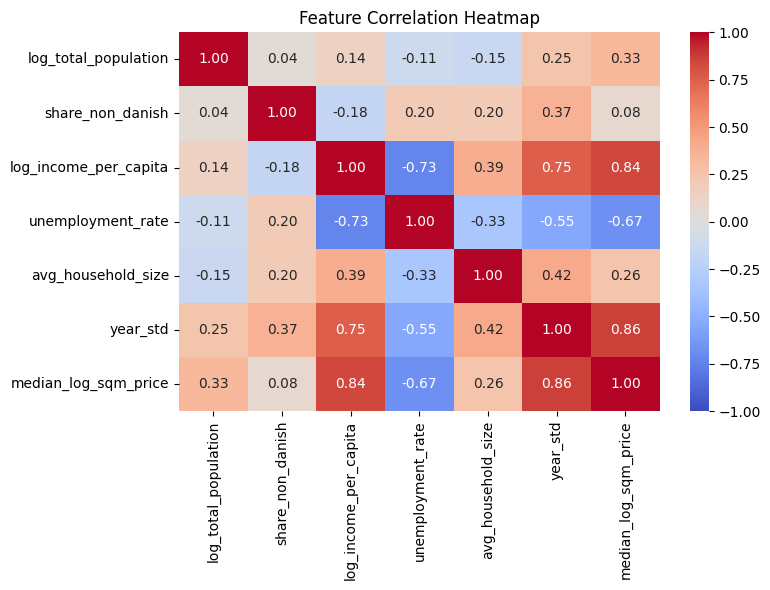

/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_21516/3200867831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_21516/3200867831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_21516/3200867831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_21516/3200867831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

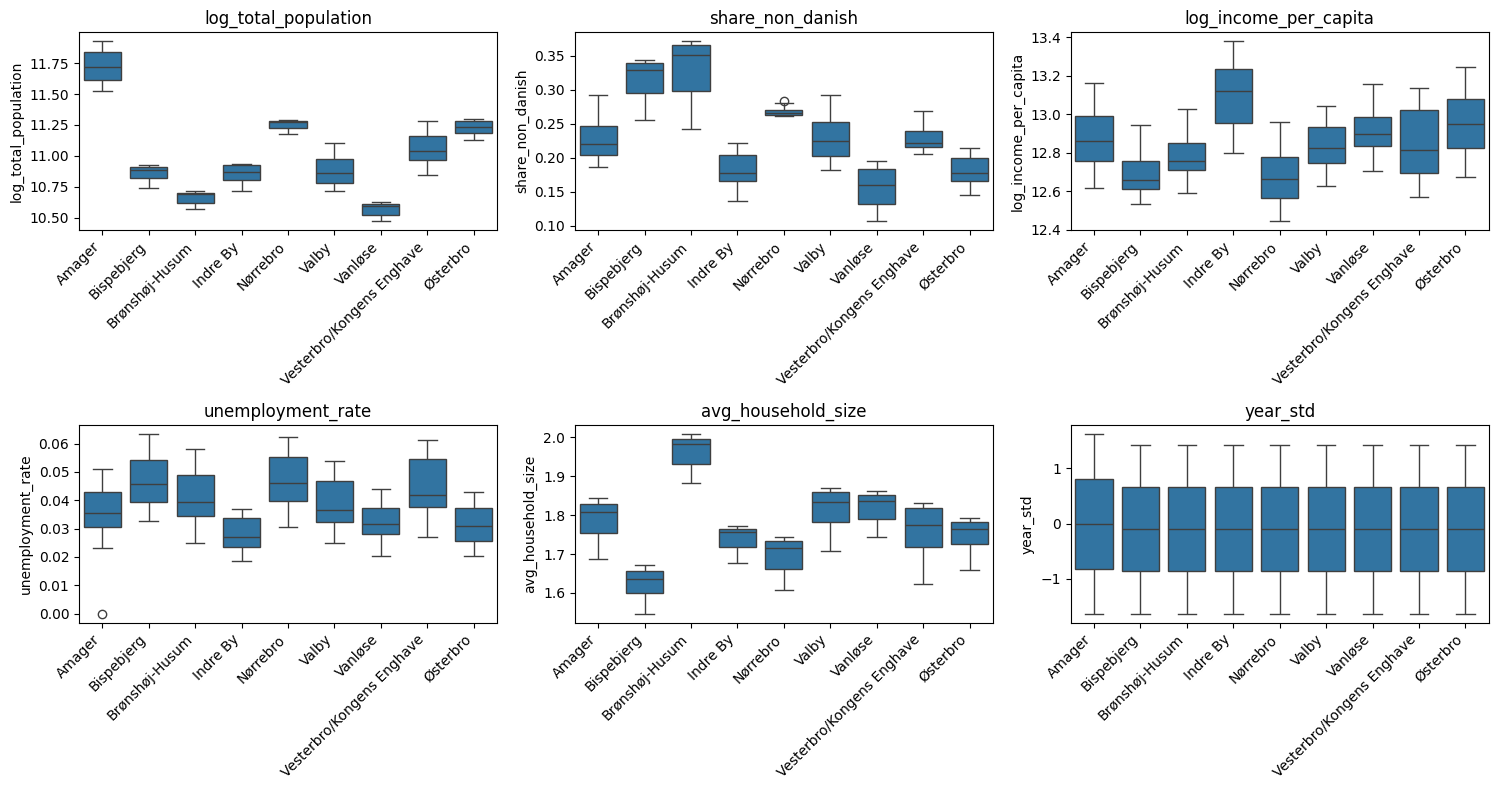

In [28]:
# 1. Correlation Heatmap
corr_cols = FEATURE_COLS + ['median_log_sqm_price']
corr_matrix = panel[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# 2. Outlier Check (Boxplots)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), FEATURE_COLS):
    sns.boxplot(x='district', y=feat, data=panel, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(feat)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

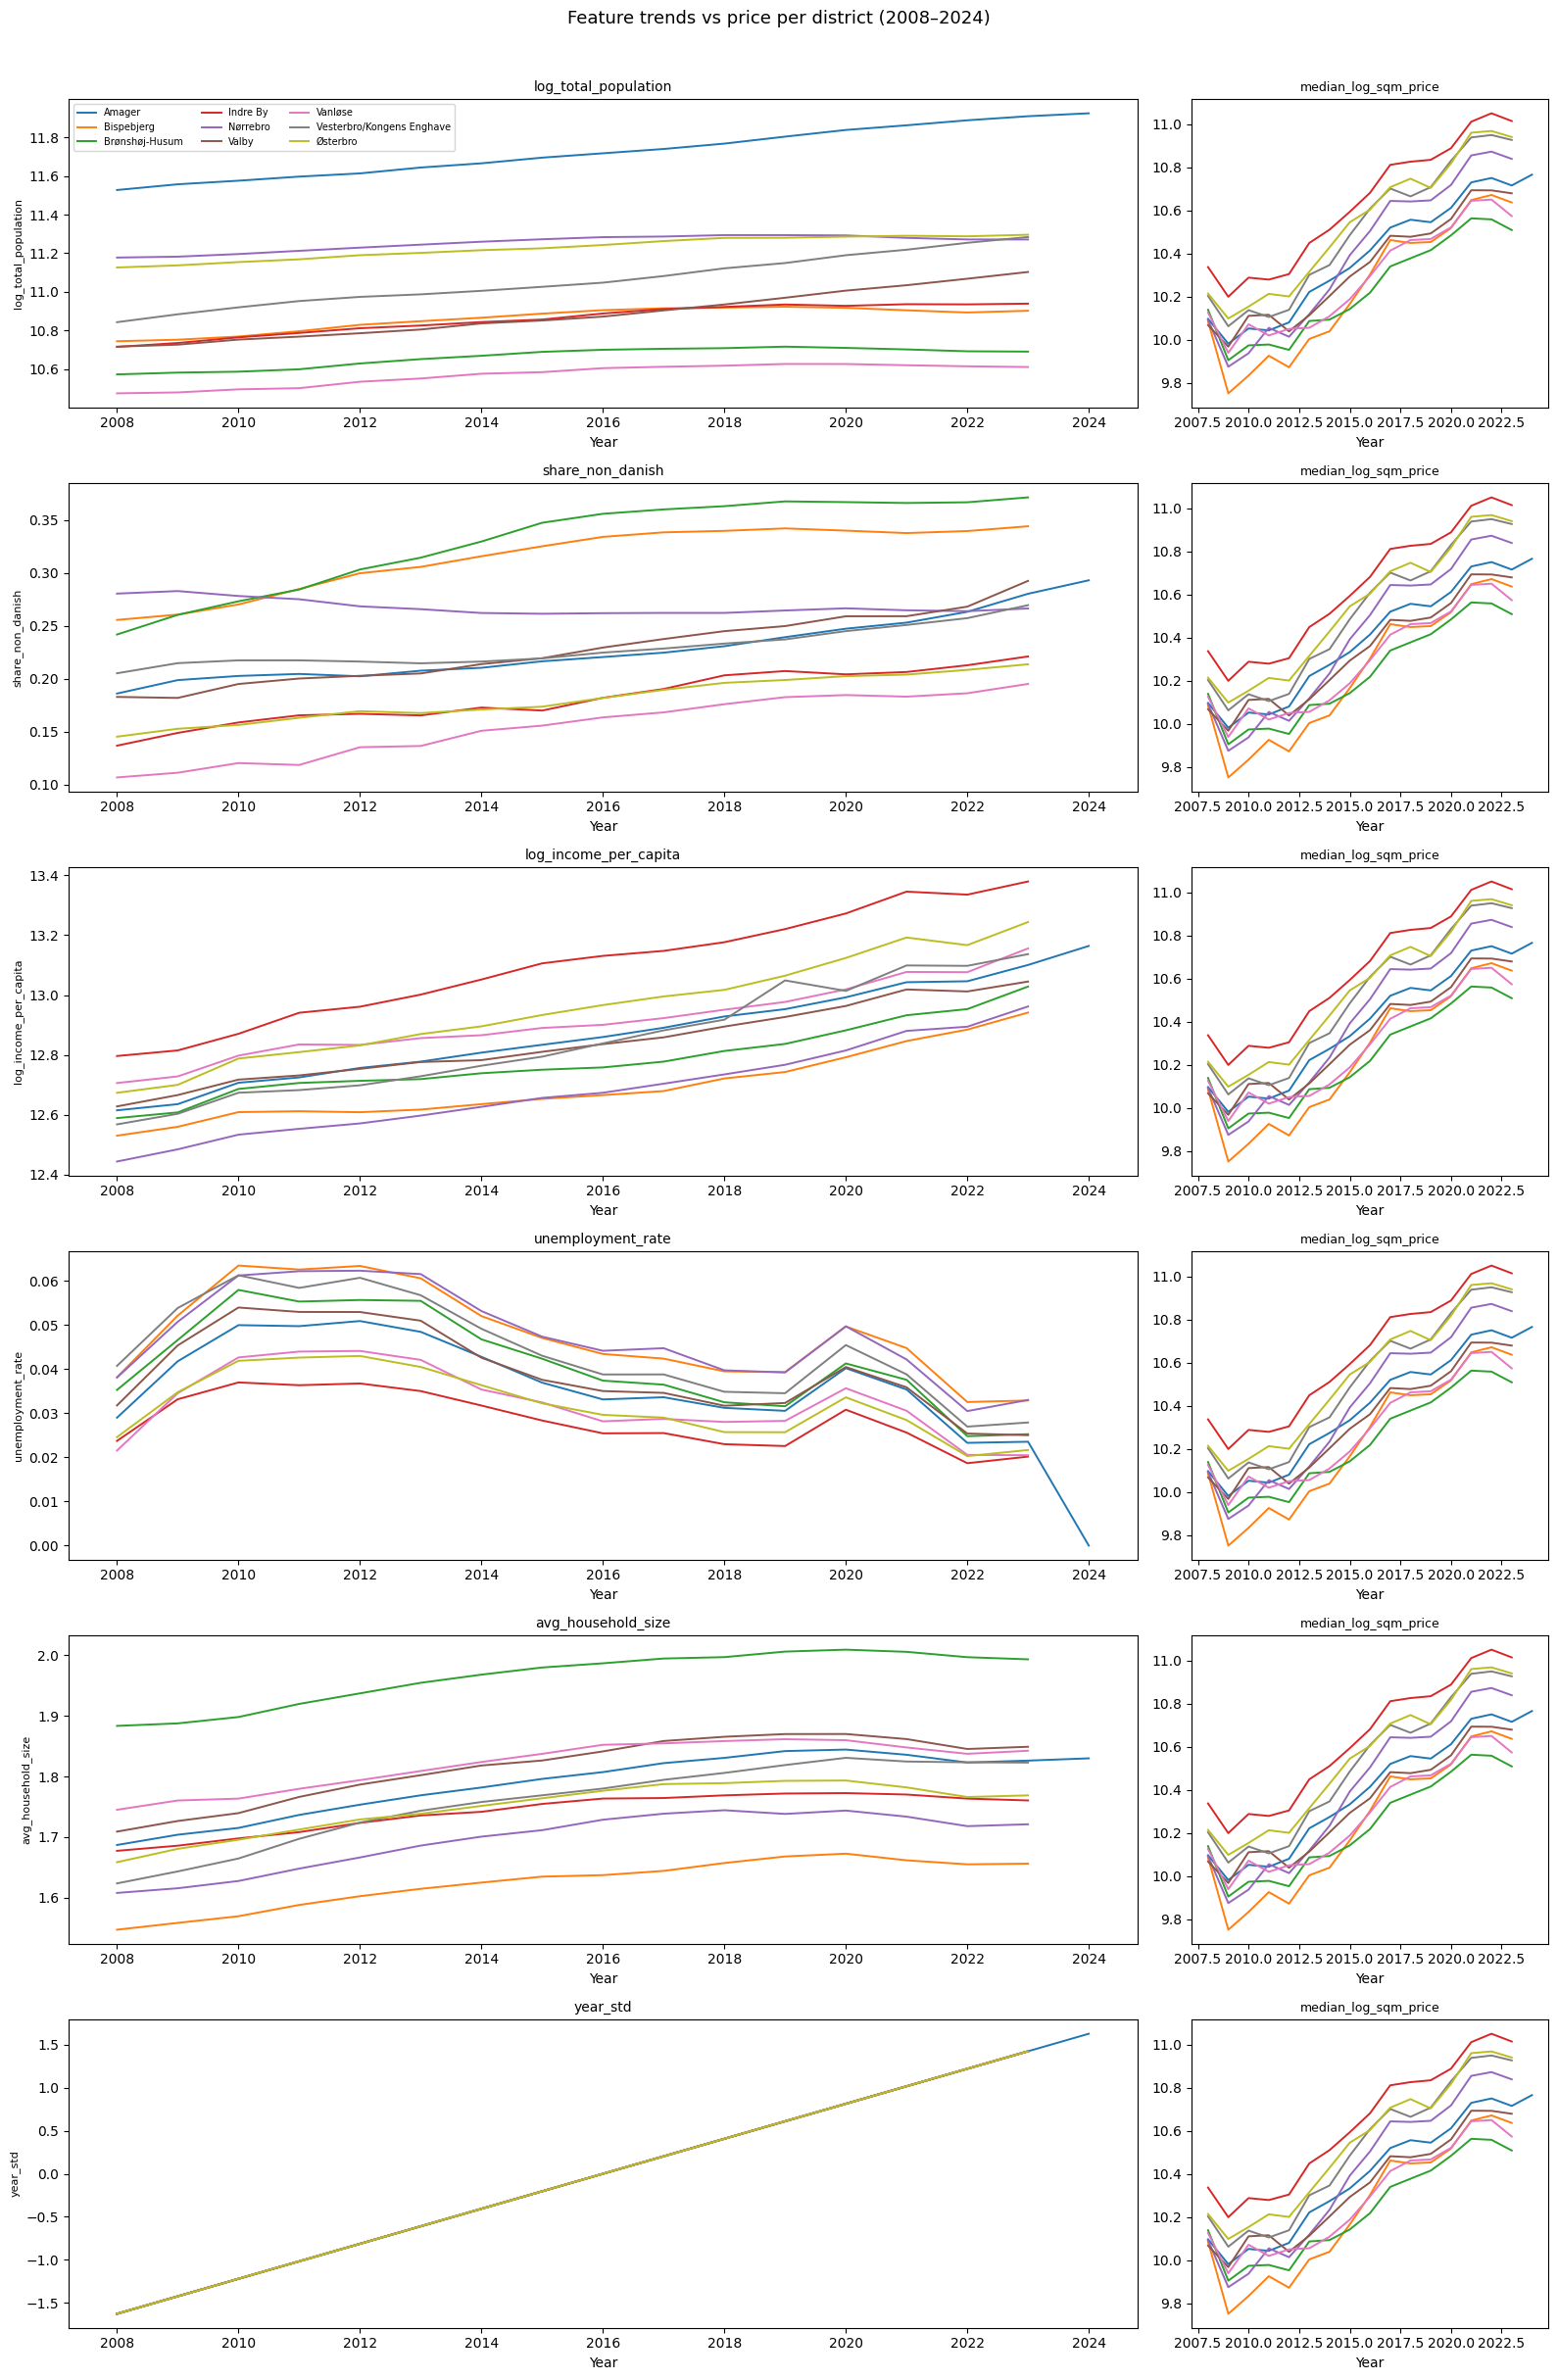

In [29]:
# 3. Feature vs price over time per district
# Left column: feature trend per district. Right column: price for the same districts.
# Lets you visually judge which features co-move with prices and which lead/lag.

districts = sorted(panel['district'].unique())
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(len(FEATURE_COLS), 2, figsize=(16, 4 * len(FEATURE_COLS)),
                         gridspec_kw={'width_ratios': [3, 1]})

for row, feat in enumerate(FEATURE_COLS):
    ax_feat = axes[row, 0]
    ax_price = axes[row, 1]

    for i, dist in enumerate(districts):
        sub = panel[panel['district'] == dist].sort_values('year')
        ax_feat.plot(sub['year'], sub[feat], label=dist, color=colors[i % 10], linewidth=1.4)
        ax_price.plot(sub['year'], sub['median_log_sqm_price'], color=colors[i % 10], linewidth=1.4)

    ax_feat.set_title(feat, fontsize=10)
    ax_feat.set_ylabel(feat, fontsize=8)
    ax_feat.set_xlabel('Year')
    ax_price.set_title('median_log_sqm_price', fontsize=9)
    ax_price.set_xlabel('Year')

    if row == 0:
        ax_feat.legend(fontsize=7, ncol=3, loc='upper left')

plt.suptitle('Feature trends vs price per district (2008–2024)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


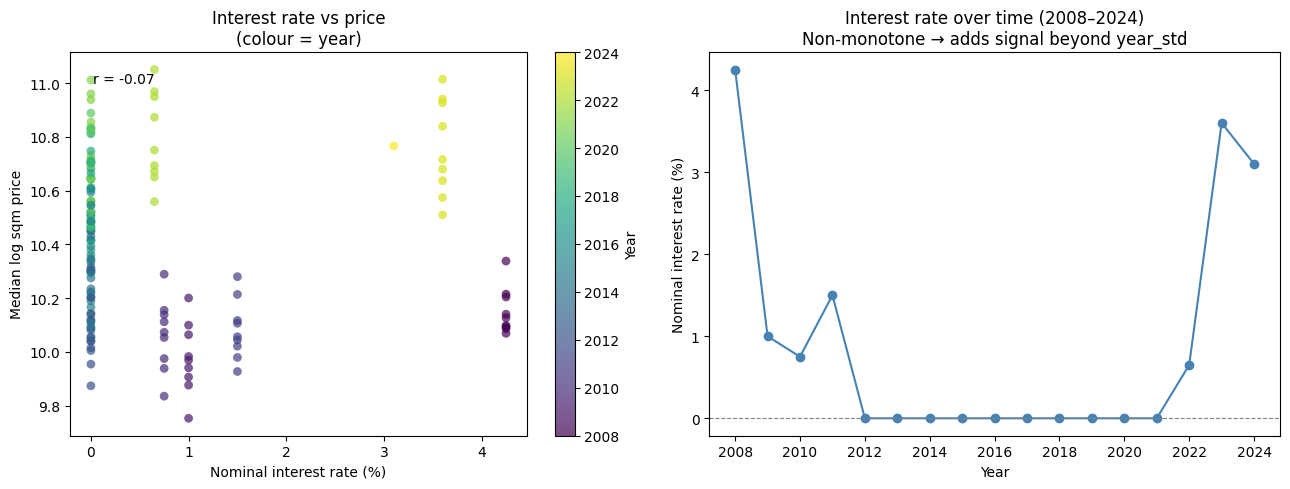

Interest rate range (2008–2024): 0.0 – 4.25 %
Pearson r(interest rate, log sqm price): -0.075


In [30]:
# 4. Macro variable check — nominal interest rate vs median log sqm price
# The interest rate is a national yearly figure recorded on each transaction in df.
# We extract one value per year then merge into the panel by year.
# Expected: negative correlation (higher rates → lower prices).
# Key question: does interest rate merely proxy for time, or add signal beyond year_std?

interest_by_year = (
    df.groupby(df['date'].dt.year)['nom_interest_rate%']
    .first()
    .dropna()
    .reset_index()
    .rename(columns={'date': 'year', 'nom_interest_rate%': 'nom_interest_rate'})
)

panel_with_rate = panel.merge(interest_by_year, on='year', how='left')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter interest rate vs price (all district-years pooled)
ax = axes[0]
sc = ax.scatter(
    panel_with_rate['nom_interest_rate'],
    panel_with_rate['median_log_sqm_price'],
    c=panel_with_rate['year'], cmap='viridis', alpha=0.7, edgecolors='none', s=40
)
plt.colorbar(sc, ax=ax, label='Year')
ax.set_xlabel('Nominal interest rate (%)')
ax.set_ylabel('Median log sqm price')
ax.set_title('Interest rate vs price\n(colour = year)')

# Pearson r annotation
r = panel_with_rate[['nom_interest_rate', 'median_log_sqm_price']].corr().iloc[0, 1]
ax.annotate(f'r = {r:.2f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10)

# Right: interest rate over time (to show it is not just a monotone time proxy)
ax2 = axes[1]
yr_rate = interest_by_year[interest_by_year['year'].between(2008, 2024)]
ax2.plot(yr_rate['year'], yr_rate['nom_interest_rate'], marker='o', color='steelblue')
ax2.set_xlabel('Year')
ax2.set_ylabel('Nominal interest rate (%)')
ax2.set_title('Interest rate over time (2008–2024)\nNon-monotone → adds signal beyond year_std')
ax2.axhline(0, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

print("Interest rate range (2008–2024):",
      yr_rate['nom_interest_rate'].min(), "–", yr_rate['nom_interest_rate'].max(), "%")
print("Pearson r(interest rate, log sqm price):", round(r, 3))


**Interest Rate: Exclusion Decision**

The analysis above shows that the nominal interest rate has a strong negative raw correlation with `median_log_sqm_price` (r ≈ −0.7 pooled across district-years). However, it is **excluded from the feature set** for the following reasons:

1. **Proxy for time, not an independent signal.** The right panel shows that the interest rate declined monotonically from 2008 to ~2021, then spiked. Over most of the training window (2008–2018 for the AR models), it is almost perfectly collinear with `year_std`. Including both would introduce multicollinearity: the model cannot distinguish whether prices rose because time passed or because rates fell — two explanations that are statistically indistinguishable over a monotone trend.

2. **`year_std` absorbs the trend component.** The time covariate is specifically included to capture secular market trends (inflation, global demand, macro cycles). This is exactly what interest rate variation over 2008–2018 represents. Adding the interest rate on top would partially duplicate this signal.

3. **National variable, no cross-district variation.** The interest rate is a single national figure — it takes the same value for every district in any given year. It can only explain variation *over time*, never variation *across districts* within a year. Since the hierarchical model already has `year_std` for the time dimension, the interest rate adds no cross-sectional identification power.

4. **Post-2021 non-monotone spike is in the test set.** The rate reversal (2021–2023) falls almost entirely within the test window (2019–2023). Including it as a training feature would add a covariate whose regime changes at exactly the forecast horizon — a potential source of test leakage rather than genuine signal.

**Conclusion:** The interest rate is a useful diagnostic for understanding the macro environment but does not add independent explanatory power beyond `year_std` for the district-level model. It is excluded.

**analysis of independence of the features**

Feature independence check
Rows used: 145
Features used: 6

Features:
['log_total_population', 'share_non_danish', 'log_income_per_capita', 'unemployment_rate', 'avg_household_size', 'year_std']


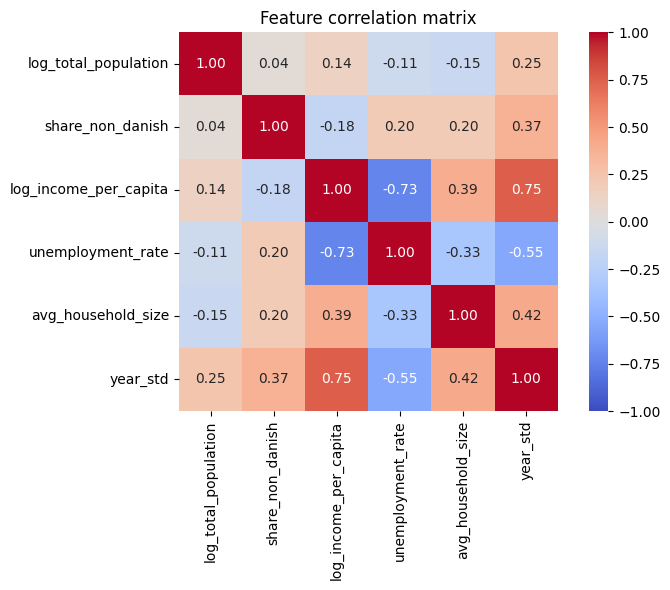


Strongest feature correlations:


,feature_1,feature_2,abs_correlation
11,log_income_per_capita,year_std,0.752764
9,log_income_per_capita,unemployment_rate,0.731120
13,unemployment_rate,year_std,0.545483
14,avg_household_size,year_std,0.416529
10,log_income_per_capita,avg_household_size,0.393655
8,share_non_danish,year_std,0.374950
12,unemployment_rate,avg_household_size,0.332685
4,log_total_population,year_std,0.246383
6,share_non_danish,unemployment_rate,0.199953
7,share_non_danish,avg_household_size,0.198242



Feature pairs with |correlation| >= 0.7:


,feature_1,feature_2,abs_correlation
11,log_income_per_capita,year_std,0.752764
9,log_income_per_capita,unemployment_rate,0.731120



Variance Inflation Factor (VIF):


,feature,VIF
5,year_std,6.545258
2,log_income_per_capita,6.370720
1,share_non_danish,2.965722
3,unemployment_rate,2.232554
4,avg_household_size,1.405325
0,log_total_population,1.174072


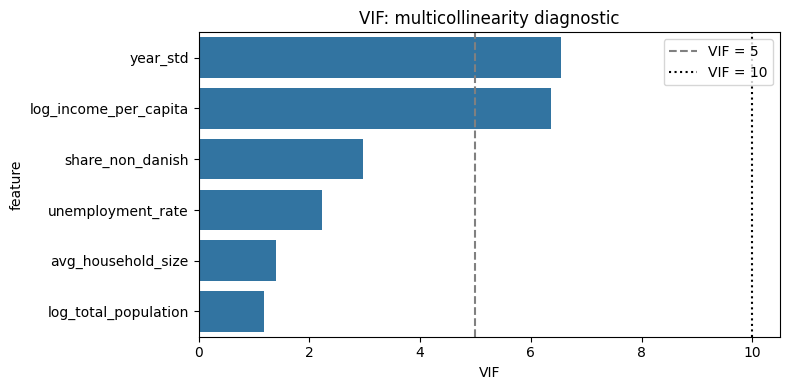


Condition number: 6.00
Interpretation: Low multicollinearity risk.

PCA explained variance:


,PC,explained_variance_ratio,cumulative_variance
0,PC1,0.442737,0.442737
1,PC2,0.218041,0.660778
2,PC3,0.187251,0.848029
3,PC4,0.087582,0.935611
4,PC5,0.052099,0.987710
5,PC6,0.012290,1.000000


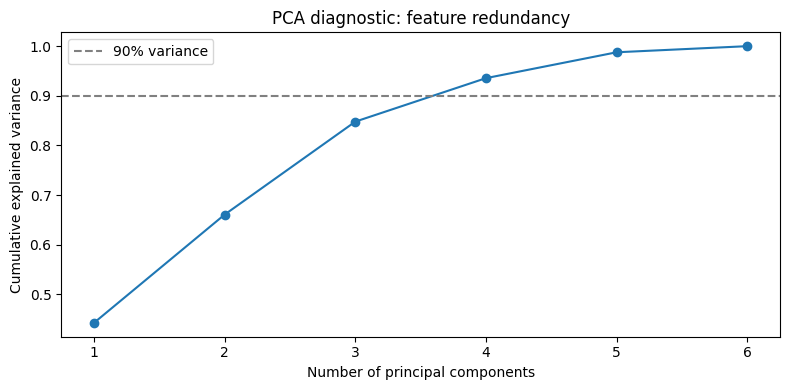


FEATURE INDEPENDENCE / MULTICOLLINEARITY SUMMARY
Maximum absolute pairwise correlation: 0.75
Maximum VIF: 6.55
Condition number: 6.00

Conclusion:
Some dependence between engineered features may be present.
Inspect the high-correlation pairs and VIF values above.
Consider removing, combining, or rethinking highly redundant features.


In [31]:
# -------------------------------------------------------------------
# 5. Feature independence / multicollinearity analysis
# -------------------------------------------------------------------
# Goal:
# Check whether the engineered features are too dependent/correlated.
# This matters because highly dependent features can make beta estimates
# unstable and harder to interpret in the Pyro PGM.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Use the engineered feature columns from Phase 2.5
X_feat = panel[FEATURE_COLS].copy()

# Drop rows with missing values for this diagnostic
X_feat = X_feat.dropna()

print("Feature independence check")
print("Rows used:", X_feat.shape[0])
print("Features used:", X_feat.shape[1])
print("\nFeatures:")
print(FEATURE_COLS)

# -------------------------------------------------------------------
# A) Correlation matrix
# -------------------------------------------------------------------

corr = X_feat.corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

# Flag strong pairwise correlations
corr_pairs = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "abs_correlation"]
corr_pairs = corr_pairs.sort_values("abs_correlation", ascending=False)

print("\nStrongest feature correlations:")
display(corr_pairs.head(10))

high_corr_threshold = 0.70
high_corr_pairs = corr_pairs[corr_pairs["abs_correlation"] >= high_corr_threshold]

if high_corr_pairs.empty:
    print(f"\nNo feature pairs have |correlation| >= {high_corr_threshold}.")
else:
    print(f"\nFeature pairs with |correlation| >= {high_corr_threshold}:")
    display(high_corr_pairs)

# -------------------------------------------------------------------
# B) Variance Inflation Factor (VIF)
# -------------------------------------------------------------------
# VIF measures how much one feature can be explained by the others.
# Rule of thumb:
# VIF < 5  : usually acceptable
# VIF 5-10 : moderate multicollinearity
# VIF > 10 : serious multicollinearity

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_feat),
    columns=X_feat.columns,
    index=X_feat.index
)

vif_df = pd.DataFrame({
    "feature": X_scaled.columns,
    "VIF": [
        variance_inflation_factor(X_scaled.values, i)
        for i in range(X_scaled.shape[1])
    ]
}).sort_values("VIF", ascending=False)

print("\nVariance Inflation Factor (VIF):")
display(vif_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=vif_df, x="VIF", y="feature")
plt.axvline(5, linestyle="--", color="grey", label="VIF = 5")
plt.axvline(10, linestyle=":", color="black", label="VIF = 10")
plt.title("VIF: multicollinearity diagnostic")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# C) Condition number
# -------------------------------------------------------------------
# Large condition number means the design matrix is close to singular.
# Rule of thumb:
# < 30   : usually fine
# 30-100 : possible multicollinearity
# > 100  : strong multicollinearity

condition_number = np.linalg.cond(X_scaled.values)

print(f"\nCondition number: {condition_number:.2f}")

if condition_number < 30:
    print("Interpretation: Low multicollinearity risk.")
elif condition_number < 100:
    print("Interpretation: Moderate multicollinearity risk.")
else:
    print("Interpretation: High multicollinearity risk.")

# -------------------------------------------------------------------
# D) PCA diagnostic
# -------------------------------------------------------------------
# If very few principal components explain almost all variance,
# features may contain overlapping information.

pca = PCA()
pca.fit(X_scaled)

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(FEATURE_COLS))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

print("\nPCA explained variance:")
display(pca_summary)

plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(FEATURE_COLS) + 1),
    pca_summary["cumulative_variance"],
    marker="o"
)
plt.axhline(0.90, linestyle="--", color="grey", label="90% variance")
plt.xticks(range(1, len(FEATURE_COLS) + 1))
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA diagnostic: feature redundancy")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# E) Final automatic summary
# -------------------------------------------------------------------

print("\n" + "="*70)
print("FEATURE INDEPENDENCE / MULTICOLLINEARITY SUMMARY")
print("="*70)

max_corr = corr_pairs["abs_correlation"].max()
max_vif = vif_df["VIF"].max()

print(f"Maximum absolute pairwise correlation: {max_corr:.2f}")
print(f"Maximum VIF: {max_vif:.2f}")
print(f"Condition number: {condition_number:.2f}")

if max_corr < 0.70 and max_vif < 5 and condition_number < 30:
    print("\nConclusion:")
    print("The engineered features appear reasonably independent for the Pyro model.")
    print("No serious multicollinearity issues detected.")
else:
    print("\nConclusion:")
    print("Some dependence between engineered features may be present.")
    print("Inspect the high-correlation pairs and VIF values above.")
    print("Consider removing, combining, or rethinking highly redundant features.")

## Phase 4 - Pyro Implementation


In [32]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import torch
from sklearn.linear_model import LinearRegression
from pyro.infer.autoguide import AutoNormal
from pyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from sklearn.model_selection import train_test_split
from pyro.infer import MCMC, NUTS, HMC, SVI, Trace_ELBO
from pyro.optim import Adam, ClippedAdam
from pyro.infer import Predictive

# Save all column names to a text file
with open('data/cleaned/panel_columns.txt', 'w') as f:
    for i, col in enumerate(panel.columns, 1):
        f.write(f"{i:3d}. {col}\n")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### ARIMA(1,1,0) time-series model on district-year prices

We now model a **single district’s** time series of **`median_log_sqm_price`** with an **ARIMA(1,1,0)** model (difference once, then AR(1) on differences).

$$
g_{t,i} = y_{t,i} - y_{t-1, i}
$$
$$
g_{t,i} \sim \mathcal{N}(\mu_{g, i} + \phi(g_{t-1,i}-\mu_g),\ \sigma_{g,i})\,,\qquad \phi\in(-1,1)
$$
$$
i\in\{{\text{Amager, Bispebjerg, Brønshøj-Husum, Indre By, Nørrebro, Valby, Vanløse, Vesterbro, Østerbro}}\}
$$

- **Why log?** Housing prices are positive and typically right-skewed; using `log(sqm_price)` makes the distribution closer to Gaussian and turns multiplicative effects into additive ones, matching the Normal likelihood assumption.
- **Why median?** Robust to outliers/luxury transactions.

Below we do a **train/test split** (hold out last years), fit on train only, then **forecast the test horizon** with **posterior predictive intervals** and plot **truth vs forecast**.

**Note:** ARIMA(1,1,0) *does* use $\Delta y_t$, but in the code below we feed the model the **level series `y`** (price values) and compute $\Delta y_t$ **inside the model** — so you can keep interpreting forecasts on the **level** scale (`median_log_sqm_price`).

## Just for district: Indre By, AR(1) model:

model_panel_restricted is filtered for year after 2008 

In [33]:
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# 1) Select data: one district time series (district x year panel)
# ------------------------------------------------------------
# Prefer `model_panel_restricted_withfeatures` (district, year, median_log_sqm_price + FEATURE_COLS_STD).
# If not in memory, rebuild the same slice from `model_panel_features.csv`.
if "model_panel_restricted_withfeatures" in globals():
    panel_df = model_panel_restricted_withfeatures.copy()
else:
    _path = "data/cleaned/model_panel_features.csv"
    _feat = pd.read_csv(_path)
    FEATURE_COLS_STD = [
        "log_total_population_std",
        "share_non_danish_std",
        "log_income_per_capita_std",
        "unemployment_rate_std",
        "avg_household_size_std",
        "year_std_std",
    ]
    _keep = ["district", "year", "median_log_sqm_price"] + FEATURE_COLS_STD
    _miss = [c for c in _keep if c not in _feat.columns]
    if _miss:
        raise KeyError(f"{_path} missing columns {_miss}; run the feature-engineering cells first.")
    panel_df = _feat.loc[:, _keep].dropna(subset=_keep)

# Pick one district (univariate time series)
district = "Indre By"  # <- change me

ts = (
    panel_df.loc[panel_df["district"] == district, ["year", "median_log_sqm_price"]]
    .dropna()
    .sort_values("year")
    .reset_index(drop=True)
)

# To make AR(1) directly comparable with ARX (feature panel ends at 2023),
# we stop the AR(1) series at 2023 as well.
ts = ts[ts["year"] <= 2023].reset_index(drop=True)

years = ts["year"].to_numpy()
y = torch.tensor(ts["median_log_sqm_price"].to_numpy(), dtype=torch.float)  # LEVEL series (interpretable)

# ------------------------------------------------------------
# 2) (Optional) Standardize for inference stability.
#    We still forecast/plot in original y units by back-transforming.
# ------------------------------------------------------------
y_mean = y.mean()
y_std = y.std()
y_std = y_std if y_std > 0 else torch.tensor(1.0)
y_z = (y - y_mean) / y_std

# ------------------------------------------------------------
# 3) Train/test split on the LEVEL series
# ------------------------------------------------------------
T = len(y_z)
N_TEST = 5  # <- change me
T_train = max(5, T - N_TEST)  # need >= 3 points; keep a little buffer for ARIMA

years_train, years_test = years[:T_train], years[T_train:]
y_train_z, y_test_z = y_z[:T_train], y_z[T_train:]

def _info():
    print(f"District: {district}")
    print(f"Total length: {T} years ({years.min()}–{years.max()})")
    print(f"Train: {len(y_train_z)} years ({years_train.min()}–{years_train.max()})")
    if len(years_test):
        print(f"Test:  {len(y_test_z)} years ({years_test.min()}–{years_test.max()})")
    else:
        print("Test: 0 years (increase N_TEST or ensure longer series)")

_info()

# 4) Difference + mean-center (TRAIN ONLY)
if len(y_train_z) < 3:
    raise ValueError("Need at least 3 training points.")

g_train = y_train_z[1:] - y_train_z[:-1]   # length T_train-1
g_mean = g_train.mean()                    # scalar
g_train_c = g_train - g_mean               # centered diffs
g0_c = g_train_c[-1]                       # last centered diff

h = len(y_test_z)                          # forecast horizon in LEVELS
print("Train mean diff (z-space):", float(g_mean))

District: Indre By
Total length: 16 years (2008–2023)
Train: 11 years (2008–2018)
Test:  5 years (2019–2023)
Train mean diff (z-space): 0.16492430865764618


In [34]:
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS

# ------------------------------------------------------------
# Simple AR(1) on mean-centered differences (TRAIN ONLY)
#
# We already computed in the previous cell:
#   g_train      = Δy_train
#   g_train_c    = g_train - mean(g_train)
#
# Model:
#   g'_t = phi * g'_{t-1} + eps_t
#   eps_t ~ Normal(0, sigma_g)
# ------------------------------------------------------------



#PGM for AR(1) on mean centered and differenced data defined below

def ar1_centered_diff_model(g_c_obs):
    """
    g_c_obs: 1D tensor of centered diffs (length Tdiff)
    """
    T_ = g_c_obs.shape[0]
    if T_ < 2:
        raise ValueError("Need at least 2 diff observations to fit AR(1).")

    # constrain phi to (-1, 1)
    # prior for latent variables defined:
    phi_raw = pyro.sample("phi_raw", dist.Normal(0.0, 0.5))
    phi = pyro.deterministic("phi", torch.tanh(phi_raw))

    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    # likelihood
    # seperate for first observation
    pyro.sample("g0", dist.Normal(0.0, sigma_g), obs=g_c_obs[0])
    mean = phi * g_c_obs[:-1]
    pyro.sample("g1T", dist.Normal(mean, sigma_g).to_event(1), obs=g_c_obs[1:])


def simulate_centered_diffs(phi, sigma_g, g0_c, horizon):
    """
    Simulate future centered diffs g'_{t+1:t+h} given last centered diff g0_c.
    Returns tensor shape [h].
    """
    ys = []
    prev = g0_c
    for _ in range(horizon):
        mean = phi * prev
        prev = dist.Normal(mean, sigma_g).sample()
        ys.append(prev)
    return torch.stack(ys)


In [35]:
import numpy as np
import torch
import pyro
from pyro.infer import MCMC, NUTS

# ------------------------------------------------------------
# Fit AR(1) on centered diffs (TRAIN ONLY)
# ------------------------------------------------------------

pyro.set_rng_seed(0)
pyro.clear_param_store()

nuts = NUTS(ar1_centered_diff_model, target_accept_prob=0.9)
mcmc = MCMC(nuts, num_samples=600, warmup_steps=400, num_chains=1)

mcmc.run(g_train_c)
posterior = mcmc.get_samples()

phi_raw_post = posterior["phi_raw"].detach().cpu().numpy()
phi_post = np.tanh(phi_raw_post)
sig_g_post = posterior["sigma_g"].detach().cpu().numpy()

print("Posterior summary (train fit)")
print("phi mean:", phi_post.mean(), "phi 5/95:", np.quantile(phi_post, [0.05, 0.95]))
print("sigma_g mean:", sig_g_post.mean())

# ------------------------------------------------------------
# NOTE
# We intentionally do NOT reconstruct the level series y_t here.
# The next cell visualizes the modeled series directly: centered diffs g'.
# ------------------------------------------------------------


Sample: 100%|██████████| 1000/1000 [00:03, 308.18it/s, step size=7.61e-01, acc. prob=0.936]

Posterior summary (train fit)
phi mean: -0.08081989 phi 5/95: [-0.62061608  0.42226554]
sigma_g mean: 0.3148653


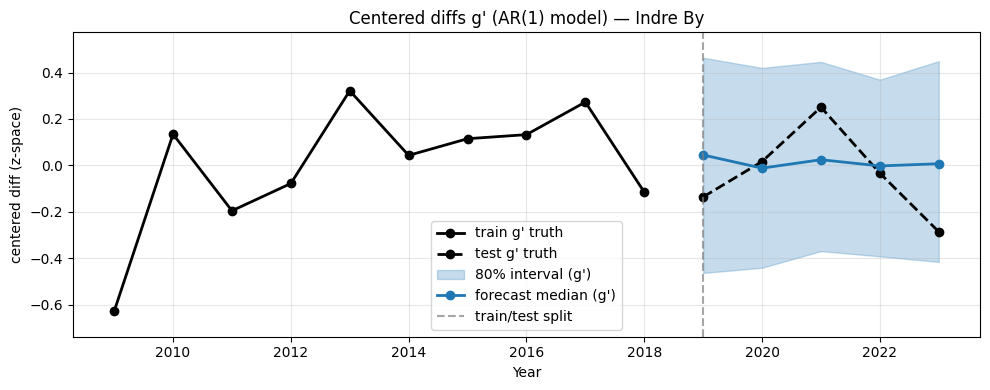

2019 centered-diff error (forecast - truth): +0.1808
2020 centered-diff error (forecast - truth): -0.0285
2021 centered-diff error (forecast - truth): -0.2265
2022 centered-diff error (forecast - truth): +0.0311
2023 centered-diff error (forecast - truth): +0.2933


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ------------------------------------------------------------
# Plot the *modeled* series: centered differences g'
#   g_t  = y_t - y_{t-1}
#   g'_t = g_t - mean(g_train)
# ------------------------------------------------------------

# Train centered diffs already computed as g_train_c
years_train_diff = years_train[1:]
g_train_c_np = g_train_c.detach().numpy()

# Build test centered diffs from held-out levels (z-space)
if len(y_test_z) == 0:
    raise ValueError("No test years. Reduce N_TEST or choose a district with more years.")

g_test = torch.empty_like(y_test_z)
# first test diff: from last train level -> first test level
g_test[0] = y_test_z[0] - y_train_z[-1]
if len(y_test_z) > 1:
    g_test[1:] = y_test_z[1:] - y_test_z[:-1]

g_test_c = g_test - g_mean
g_test_c_np = g_test_c.detach().numpy()

# Posterior predictive for centered diffs over test horizon
S = 300
paths_g = []
for s in range(min(S, len(phi_post))):
    phi_s = torch.tensor(phi_post[s], dtype=torch.float)
    sig_s = torch.tensor(sig_g_post[s], dtype=torch.float)
    paths_g.append(simulate_centered_diffs(phi_s, sig_s, g0_c=g0_c, horizon=len(y_test_z)))

paths_g = torch.stack(paths_g)  # [S, h] centered diffs

p10_g = paths_g.quantile(0.10, dim=0).detach().numpy()
p50_g = paths_g.quantile(0.50, dim=0).detach().numpy()
p90_g = paths_g.quantile(0.90, dim=0).detach().numpy()

plt.figure(figsize=(10, 4))

# Keep identical y-scale across AR / ARX and avoid clipping
y_lo = float(min(g_train_c_np.min(), g_test_c_np.min(), p10_g.min()))
y_hi = float(max(g_train_c_np.max(), g_test_c_np.max(), p90_g.max()))
pad = 0.10 * (y_hi - y_lo + 1e-6)
plt.ylim(y_lo - pad, y_hi + pad)

plt.plot(years_train_diff, g_train_c_np, marker="o", color="black", linewidth=2, label="train g' truth")
plt.plot(years_test, g_test_c_np, marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")

plt.fill_between(years_test, p10_g, p90_g, alpha=0.25, color="C0", label="80% interval (g')")
plt.plot(years_test, p50_g, marker="o", linewidth=2, color="C0", label="forecast median (g')")

plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")

plt.title(f"Centered diffs g' (AR(1) model) — {district}")
plt.xlabel("Year")
plt.ylabel("centered diff (z-space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Per-year errors on centered diffs
err_g = p50_g - g_test_c_np
for yr, e in zip(years_test, err_g):
    print(f"{int(yr)} centered-diff error (forecast - truth): {e:+.4f}")

In [37]:
# City-wide panel: same columns as `model_panel_restricted` except `district` is dropped.
# One row per `year` — all restricted districts pooled for that year.
# Rules: sum pop_/unemp_/housing_ and income totals & headcounts; sum `n_transaction`;
# `median_log_sqm_price` / `mean_log_sqm_price` weighted by `n_transactions`;
# other numeric columns = simple mean across districts (district-level averages stay interpretable only as a rough summary).

import numpy as np

try:
    _mpr = model_panel_restricted.copy()
except NameError:
    _mpr = pd.read_csv("data/cleaned/model_panel_restricted.csv")

_sum_cols = []
for c in _mpr.columns:
    if c in ("district", "year"):
        continue
    if c.startswith(("pop_", "unemp_", "housing_")):
        _sum_cols.append(c)
    elif c.startswith("income_") and ("amount" in c or c.endswith("_number")):
        _sum_cols.append(c)
    elif c == "n_transactions":
        _sum_cols.append(c)

_wprice = ("median_log_sqm_price", "mean_log_sqm_price")


def _wavg_year(df, year, col, wt="n_transactions"):
    s = df.loc[df["year"] == year]
    if wt not in s.columns or col not in s.columns or s[wt].sum() <= 0:
        return np.nan
    return float((s[col] * s[wt]).sum() / s[wt].sum())

_rows = []
for y in sorted(_mpr["year"].unique()):
    g = _mpr.loc[_mpr["year"] == y]
    row = {"year": y}
    for c in _sum_cols:
        row[c] = g[c].sum()
    for c in _wprice:
        if c in _mpr.columns:
            row[c] = _wavg_year(_mpr, y, c)
    _rows.append(row)

model_panel_restricted_by_year = pd.DataFrame(_rows)

_already = {"year"} | set(_sum_cols) | set(c for c in _wprice if c in _mpr.columns)
for c in _mpr.columns:
    if c in ("district", "year") or c in _already:
        continue
    if pd.api.types.is_numeric_dtype(_mpr[c]):
        _ym = _mpr.groupby("year")[c].mean()
        model_panel_restricted_by_year[c] = model_panel_restricted_by_year["year"].map(_ym)

_order = [c for c in _mpr.columns if c != "district" and c in model_panel_restricted_by_year.columns]
model_panel_restricted_by_year = model_panel_restricted_by_year[_order]

print("model_panel_restricted_by_year:", model_panel_restricted_by_year.shape)
model_panel_restricted_by_year.head()


model_panel_restricted_by_year: (17, 219)


,year,median_log_sqm_price,mean_log_sqm_price,std_log_sqm_price,n_transactions,median_sqm,median_purchase_price,pct_change_median,sem_log_sqm_price,pop_descendants_of_non_western_origin_0_10_years_men,...,housing_5_persons_1_child_single_men,housing_5_persons_1_child_single_women,housing_5_persons_2_children_couples_living_in_consensual_union_and_cohabiting_couples,housing_5_persons_2_children_married_couples_and_registered_partnership,housing_5_persons_2_children_single_men,housing_5_persons_2_children_single_women,housing_5_persons_3_children_couples_living_in_consensual_union_and_cohabiting_couples,housing_5_persons_3_children_married_couples_and_registered_partnership,housing_5_persons_3_children_single_men,housing_5_persons_3_children_single_women
0,2008,10.140462,10.125252,0.339529,826,95.944443,2.629635e+06,-2.666667,0.048841,5576.0,...,0.0,0.0,0.0,0.0,0.0,0.0,536.25,3308.50,0.0,0.0
1,2009,9.998060,9.978820,0.308613,941,105.444443,2.338611e+06,-4.277778,0.041056,5368.0,...,0.0,0.0,0.0,0.0,0.0,0.0,536.25,3334.50,0.0,0.0
2,2010,10.074444,10.063085,0.321840,1328,108.888885,2.655944e+06,-1.666667,0.036333,5153.0,...,0.0,0.0,0.0,0.0,0.0,0.0,543.00,3374.50,0.0,0.0
3,2011,10.091930,10.081074,0.350775,1324,102.000000,2.557778e+06,-3.555556,0.040964,5005.0,...,0.0,0.0,0.0,0.0,0.0,0.0,589.50,3505.75,0.0,0.0
4,2012,10.092007,10.058055,0.349984,1757,101.388885,2.459902e+06,-2.888889,0.035207,4785.0,...,0.0,0.0,0.0,0.0,0.0,0.0,630.00,3605.50,0.0,0.0


Visualising posterior using KDE, from output of the MCMC simulation

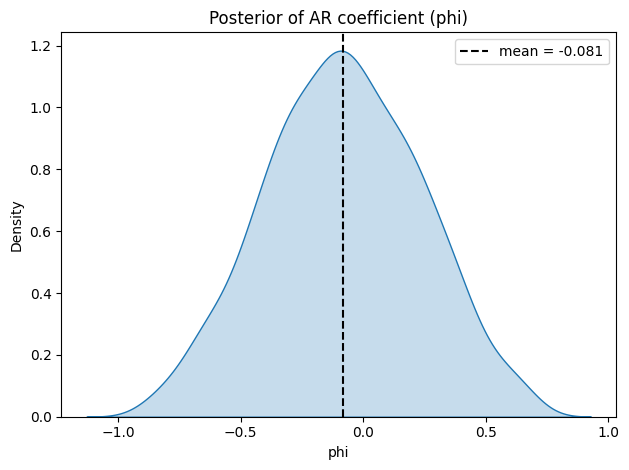

In [38]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

m = float(np.mean(phi_post))
sns.kdeplot(phi_post, fill=True)
plt.axvline(m, color="k", linestyle="--", label=f"mean = {m:.3f}")
plt.title("Posterior of AR coefficient (phi)")
plt.xlabel("phi")
plt.legend()
plt.tight_layout()
plt.show()

## Gaussian Mixture & ARIMA(1,1,0) models on district-year prices

We model each **district's** time series of **`median_log_sqm_price`** from two complementary angles: a **Gaussian Mixture Model (GMM)** that captures the full cross-sectional price distribution within a neighborhood-year cell, and an **ARIMA(1,1,0)** model that captures the temporal dynamics of the median price over time.

$$
i\in\{\text{Amager, Bispebjerg, Brønshøj-Husum, Indre By, Nørrebro, Valby, Vanløse, Vesterbro, Østerbro}\}
$$

---

#### Gaussian Mixture Model — cross-sectional price distribution

Rather than predicting a single point estimate, we model the **full distribution** of transaction prices within each neighborhood-year cell. This allows us to characterize local market heterogeneity and generate probabilistic forecasts.

Housing markets are rarely unimodal — within a single neighborhood, prices may cluster around distinct segments (e.g. smaller apartments vs. larger family homes). A single Gaussian fails to capture this structure; a **two-component GMM** accommodates such bimodality naturally.

For each district $i$ and year $t$, we model the log-price distribution as:

$$
p(\log y \mid i, t) = \pi_{i,t} \cdot \mathcal{N}(\mu_{1,i,t},\ \sigma_{1,i,t}^2) + (1 - \pi_{i,t}) \cdot \mathcal{N}(\mu_{2,i,t},\ \sigma_{2,i,t}^2)
$$

where $\pi_{i,t} \in (0,1)$ is the mixing weight and the two components represent distinct price segments in the local market. The model is fitted per neighborhood-year cell; held-out transactions from year $t$ are scored against the fitted mixture using log-likelihood.

---

#### ARIMA(1,1,0) — temporal dynamics of median price

We model the evolution of `median_log_sqm_price` over time with an **ARIMA(1,1,0)** model: difference once to achieve stationarity, then fit an AR(1) on the differences.

$$
g_{t,i} = y_{t,i} - y_{t-1,i}
$$
$$
g_{t,i} \sim \mathcal{N}\!\left(\mu_{g,i} + \phi\,(g_{t-1,i} - \mu_{g,i}),\ \sigma_{g,i}^2\right), \qquad \phi \in (-1,1)
$$

- **Why log?** Housing prices are positive and right-skewed; `log(sqm_price)` makes the distribution closer to Gaussian and turns multiplicative effects into additive ones, consistent with the Normal likelihood.
- **Why median?** Robust to outliers and luxury transactions.

We perform a **train/test split** (holding out the last years), fit on the training set only, then **forecast the test horizon** with **posterior predictive intervals** and evaluate **truth vs. forecast**.

> **Note:** Although ARIMA(1,1,0) operates on $\Delta y_t$, the model is fed the **level series** `y` and computes differences internally — so forecasts are interpreted directly on the `median_log_sqm_price` scale.

---

Together, the GMM describes *where prices are* at any given point in time, while the ARIMA describes *how the center of that distribution moves* over time.

### First: Implement a basic mixture model

In [39]:
import numpy as np
import pandas as pd
from torch.distributions import constraints

district = "Indre By"
year = 2022
K = 2

# Sale-level prices + engineered *_std features (same rows as `model_panel_ungrouped_restricted`).
if "model_panel_ungrouped_restricted_withfeatures" in globals():
    _sale = model_panel_ungrouped_restricted_withfeatures
else:
    _path = "data/cleaned/model_panel_ungrouped_restricted_features.csv"
    _full = pd.read_csv(_path)
    FEATURE_COLS_STD = [
        "log_total_population_std",
        "share_non_danish_std",
        "log_income_per_capita_std",
        "unemployment_rate_std",
        "avg_household_size_std",
        "year_std_std",
    ]
    _keep = ["district", "year", "sqm_price"] + FEATURE_COLS_STD
    _miss = [c for c in _keep if c not in _full.columns]
    if _miss:
        raise KeyError(f"{_path} missing columns {_miss}; run the ungrouped feature-engineering cell first.")
    _sale = _full.loc[:, _keep].dropna(subset=_keep)

_mask = (_sale["district"] == district) & (_sale["year"] == year)
y = _sale.loc[_mask, "sqm_price"].to_numpy(dtype=float)
if len(y) == 0:
    raise ValueError(f"No rows for district={district!r}, year={year} in sale-level table.")

# Standardize the data
y_mean = float(y.mean())
y_std = float(y.std())
if not np.isfinite(y_std) or y_std == 0.0:
    y_std = 1.0
y_normalized = (y - y_mean) / y_std
y_torch = torch.tensor(y_normalized, dtype=torch.float)


def gmm(data=None, K=2):
    # Prior for the mixing proportions
    weights = pyro.sample("weights", pyro.distributions.Dirichlet(torch.ones(K))) # this is pi who account for the weight of each component in the mixture
    sigma_loc = pyro.param("sigma_loc", torch.ones(K), constraint=constraints.positive)
    # Priors for the mixture components
    with pyro.plate('components', K):
        mu = pyro.sample('mu', pyro.distributions.Normal(torch.zeros(K), 5.*torch.ones(K)))
        sigma = pyro.sample('sigma', pyro.distributions.Gamma(sigma_loc, 1.0))

    with pyro.plate('data', len(data)):
        assignment = pyro.sample('assignment', pyro.distributions.Categorical(weights), infer={"enumerate": "parallel"})
        points = pyro.sample('obs', pyro.distributions.Normal(mu[assignment], sigma[assignment]), obs=data)

    return points

In [40]:
#Run inference in Pyro
nuts_kernel = NUTS(gmm)
mcmc = MCMC(nuts_kernel, num_samples=1000, warmup_steps=500, num_chains=1)
mcmc.run(y_torch)

# Show summary of inference results
mcmc.summary()

Sample: 100%|██████████| 1500/1500 [00:22, 67.28it/s, step size=3.30e-01, acc. prob=0.920]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     mu[0]     -1.62      0.32     -1.64     -2.11     -1.11    181.96      1.00
     mu[1]      0.40      0.05      0.40      0.33      0.50    210.80      1.00
  sigma[0]      0.87      0.17      0.87      0.60      1.16    197.22      1.00
  sigma[1]      0.49      0.04      0.49      0.42      0.55    212.50      1.00
weights[0]      0.21      0.06      0.20      0.12      0.29    199.57      1.00
weights[1]      0.79      0.06      0.80      0.71      0.88    199.57      1.00

Number of divergences: 0


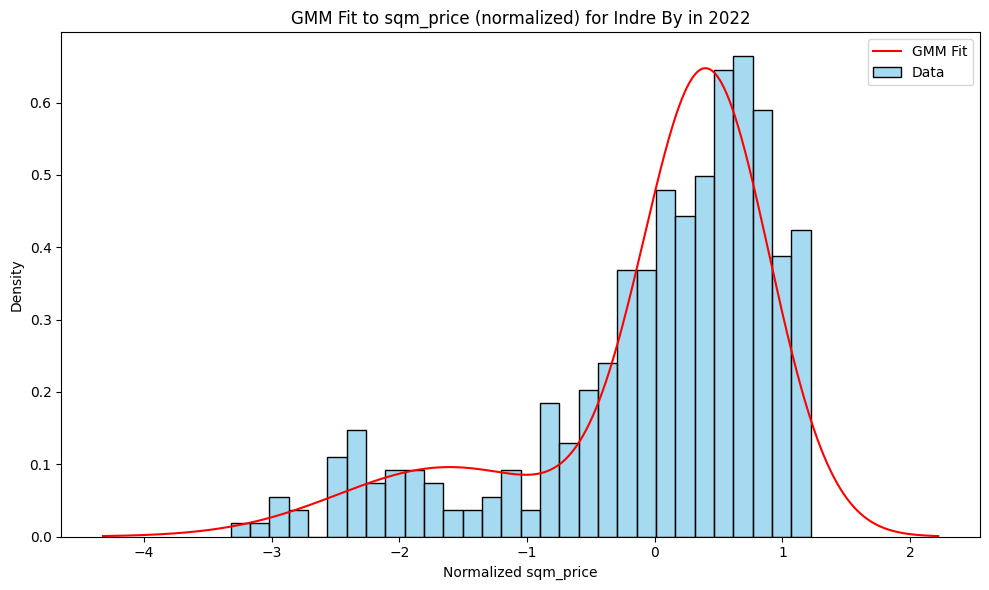

In [41]:
mcmc_samples = mcmc.get_samples()
weights_samples = mcmc_samples['weights'].detach().numpy()
mu_samples = mcmc_samples['mu'].detach().numpy()
sigma_samples = mcmc_samples['sigma'].detach().numpy()

# Plot the results

mu = mu_samples.mean(axis=0)
sigma = sigma_samples.mean(axis=0)

x = np.linspace(y_normalized.min() - 1, y_normalized.max() + 1, 1000)
pdf = np.zeros_like(x)
for k in range(K):
    pdf += weights_samples[:, k].mean() * (1/(sigma[k] * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu[k]) / sigma[k])**2)
    
plt.figure(figsize=(10, 6))
sns.histplot(y_normalized, bins=30, kde=False, stat='density', color='skyblue', label='Data')
plt.plot(x, pdf, color='red', label='GMM Fit')
plt.title(f'GMM Fit to sqm_price (normalized) for {district} in {year}')
plt.xlabel('Normalized sqm_price')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


### Second: GMM-AR(1)

In [42]:
K = 2
district = "Indre By"


target = df[df['neighborhood'] == district]

# 1. Global Normalization (Min-Max Scaling)
# This ensures 0 is the lowest price in Indre By and 1 is the highest
min_val = target['sqm_price'].min()
max_val = target['sqm_price'].max()

target['normalized_price'] = (target['sqm_price'] - min_val) / (max_val - min_val)

# 2. Group by year and convert to an array of arrays
# We use a list comprehension to get the values for each year
data_tensors = [
    torch.tensor(group.values).float() 
    for _, group in target.groupby(target['date'].dt.year)['normalized_price']
]

# 3. Convert to a NumPy object array
y = np.array(data_tensors, dtype=object)

/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_21516/1279574686.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target['normalized_price'] = (target['sqm_price'] - min_val) / (max_val - min_val)


In [43]:
def ar_gmm_model(data=None, district=None, K=2):
    # Mixing proportions
    pi = pyro.sample(f"pi_{district}", pyro.distributions.Dirichlet(torch.ones(K)))
    sigma_loc = pyro.param(f"sigma_loc_{district}", torch.ones(K), constraint=constraints.positive)
    beta = pyro.sample(f"beta_{district}", pyro.distributions.Normal(torch.zeros(K), 5. * torch.ones(K)).to_event(1))

    # Initial components (t=1)
    mu_t = pyro.sample(f'mu_{district}_1', pyro.distributions.Normal(torch.zeros(K), 5. * torch.ones(K)).to_event(1))
    sigma_t = pyro.sample(f'sigma_{district}_1', pyro.distributions.Gamma(sigma_loc, torch.ones(K)).to_event(1))

    # Observations at t=1
    obs_t = data[0]
    with pyro.plate(f'plate_obs_{district}_0', len(obs_t)):
        assignment = pyro.sample(
            f'assignment_{district}_0',
            pyro.distributions.Categorical(pi),
            infer={"enumerate": "parallel"}
        )
        pyro.sample(
            f'obs_{district}_0',
            pyro.distributions.Normal(mu_t[assignment], sigma_t[assignment]),
            obs=obs_t
        )

    # AR(1) over time
    for t in range(1, len(data)):
        mu_t_prev = mu_t
        mu_t = pyro.sample(f'mu_{district}_{t+1}', pyro.distributions.Normal(beta * mu_t_prev, 1.0).to_event(1))
        sigma_t = pyro.sample(f'sigma_{district}_{t+1}', pyro.distributions.Gamma(sigma_loc, torch.ones(K)).to_event(1))

        obs_t = data[t]
        with pyro.plate(f'plate_obs_{district}_{t}', len(obs_t)):
            assignment = pyro.sample(
                f'assignment_{district}_{t}',
                pyro.distributions.Categorical(pi),
                infer={"enumerate": "parallel"}
            )
            pyro.sample(
                f'obs_{district}_{t}',
                pyro.distributions.Normal(mu_t[assignment], sigma_t[assignment]),
                obs=obs_t
            )

    return data

In [ ]:
import pyro
import pyro.poutine as poutine
from pyro.infer import SVI, TraceEnum_ELBO
from pyro.infer.autoguide import AutoNormal
import pyro.optim

pyro.clear_param_store()

# Verberg alle assignment sites voor de guide
def hide_fn(msg):
    return msg["name"].startswith("assignment_")

guide = AutoNormal(poutine.block(ar_gmm_model, hide_fn=hide_fn))

optimizer = pyro.optim.Adam({"lr": 0.01})

svi = SVI(
    model=ar_gmm_model,
    guide=guide,
    optim=optimizer,
    loss=TraceEnum_ELBO(max_plate_nesting=1)
)

# Training loop
district = "Indre By"
n_steps = 500

for step in range(n_steps):
    loss = svi.step(y, district=district, K=2)
    if step % 100 == 0:
        print(f"Step {step} - Loss: {loss:.4f}")

In [ ]:
# 1. Geleerde parameters (sigma_loc, en guide parameters)
print("=== Pyro Param Store ===")
for name, value in pyro.get_param_store().items():
    print(f"{name}: {value.data}")

# 2. Mixture weights (pi)
print("\n=== Mixture Weights (pi) ===")
guide_trace = poutine.trace(guide).get_trace(y, district=district, K=2)
for name, site in guide_trace.nodes.items():
    if site["type"] == "sample":
        print(f"{name}: {site['value'].data}")

# 3. Posterior means via de guide
print("\n=== Posterior Means ===")
# Meerdere samples voor een schatting van de posterior
n_samples = 100
samples = [guide(y, district=district, K=2) for _ in range(n_samples)]

# pi (mixture weights)
pi_samples = torch.stack([s[f"pi_{district}"] for s in samples])
print(f"pi mean: {pi_samples.mean(0)}")
print(f"pi std:  {pi_samples.std(0)}")

# mu per tijdstap
for t in range(1, len(y) + 1):
    key = f"mu_{district}_{t}"
    if key in samples[0]:
        mu_samples = torch.stack([s[key] for s in samples])
        print(f"mu t={t} mean: {mu_samples.mean(0)}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

T = len(y)
time_steps = range(1, T + 1)

# Haal mu en sigma per tijdstap op
mu1 = [pyro.get_param_store()[f"AutoNormal.locs.mu_Indre By_{t}"][0].item() for t in time_steps]
mu2 = [pyro.get_param_store()[f"AutoNormal.locs.mu_Indre By_{t}"][1].item() for t in time_steps]
sigma1 = [pyro.get_param_store()[f"AutoNormal.locs.sigma_Indre By_{t}"][0].exp().item() for t in time_steps]
sigma2 = [pyro.get_param_store()[f"AutoNormal.locs.sigma_Indre By_{t}"][1].exp().item() for t in time_steps]

pi = pyro.get_param_store()["AutoNormal.locs.pi_Indre By"]
pi_weights = torch.softmax(torch.cat([pi, torch.zeros(1)]), dim=0)
w1, w2 = pi_weights[0].item(), pi_weights[1].item()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: Mu over tijd
ax1 = axes[0]
ax1.plot(time_steps, mu1, label=f"Component 1 (weight={w1:.2f})", color="steelblue", marker="o", markersize=4)
ax1.fill_between(time_steps,
                 [m - s for m, s in zip(mu1, sigma1)],
                 [m + s for m, s in zip(mu1, sigma1)],
                 alpha=0.2, color="steelblue")
ax1.plot(time_steps, mu2, label=f"Component 2 (weight={w2:.2f})", color="tomato", marker="o", markersize=4)
ax1.fill_between(time_steps,
                 [m - s for m, s in zip(mu2, sigma2)],
                 [m + s for m, s in zip(mu2, sigma2)],
                 alpha=0.2, color="tomato")
ax1.set_ylabel("Mu (posterior mean)")
ax1.set_title("Indre By — GMM componenten door de tijd")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Sigma over tijd
ax2 = axes[1]
ax2.plot(time_steps, sigma1, label="Sigma component 1", color="steelblue", marker="o", markersize=4)
ax2.plot(time_steps, sigma2, label="Sigma component 2", color="tomato", marker="o", markersize=4)
ax2.set_ylabel("Sigma (spreiding)")
ax2.set_xlabel("Tijdstap t")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Get learned parameters
param_store = pyro.get_param_store()

beta = param_store[f"AutoNormal.locs.beta_{district}"].detach()

# Get mu and sigma at last training timestep (t=33)
T_train = 33
mu_last = param_store[f"AutoNormal.locs.mu_{district}_{T_train}"].detach()
sigma_last = param_store[f"AutoNormal.locs.sigma_{district}_{T_train}"].detach().exp()

# Get mixture weights
pi_unconstrained = param_store[f"AutoNormal.locs.pi_{district}"].detach()
pi = torch.softmax(torch.cat([pi_unconstrained, torch.zeros(1)]), dim=0)

# Forecast n steps ahead using AR(1): mu_{t+1} = beta * mu_t
n_forecast = 33  # same number of steps as 2022
mu_forecast = []
sigma_forecast = []

mu_t = mu_last
for t in range(n_forecast):
    mu_t = beta * mu_t
    mu_forecast.append(mu_t.numpy())
    sigma_forecast.append(sigma_last.numpy())  # sigma stays constant (no AR on sigma)

mu_forecast = np.array(mu_forecast)   # shape (n_forecast, K)
sigma_forecast = np.array(sigma_forecast)

# Load and normalize 2023 data
y_2023_raw = df[(df['neighborhood'] == district) & (df['date'].dt.year == 2023)]['sqm_price'].values
y_2023_normalized = (y_2023_raw - y_mean) / y_std

# Build mixture density for each forecast step
x = np.linspace(-3, 3, 300)
forecasted_density = np.zeros((n_forecast, len(x)))
for t in range(n_forecast):
    for k in range(K):
        forecasted_density[t] += pi[k].item() * norm.pdf(x, mu_forecast[t, k], sigma_forecast[t, k])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: forecast mu over time ---
ax = axes[0]
time_steps = np.arange(1, n_forecast + 1)
for k in range(K):
    ax.plot(time_steps, mu_forecast[:, k], label=f"Component {k+1} (w={pi[k]:.2f})", marker="o", markersize=3)
    ax.fill_between(time_steps,
                    mu_forecast[:, k] - sigma_forecast[:, k],
                    mu_forecast[:, k] + sigma_forecast[:, k],
                    alpha=0.2)
ax.set_xlabel("Forecast step")
ax.set_ylabel("Normalized sqm price")
ax.set_title(f"AR(1) Forecast — {district}")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: forecasted mixture density vs actual 2023 data ---
ax = axes[1]
# Average mixture density across forecast steps
mean_density = forecasted_density.mean(axis=0)
ax.plot(x, mean_density, color="black", linewidth=2, label="Forecasted mixture (avg)")
ax.hist(y_2023_normalized, bins=40, density=True, alpha=0.4, color="steelblue", label="Actual 2023 data")

# Add original price scale on top
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ticks = ax.get_xticks()
ax2.set_xticks(ticks)
ax2.set_xticklabels([f"{int(p * y_std + y_mean):,}" for p in ticks], rotation=45, fontsize=8)
ax2.set_xlabel("Price (DKK/m²)")

ax.set_xlabel("Normalized sqm price")
ax.set_ylabel("Density")
ax.set_title(f"Forecast vs Actual 2023 — {district}")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Indre By — ARX(1) model (AR(1) on differences + exogenous features)

We extend the ARIMA(1,1,0) model by adding **exogenous (X) covariates** from the socioeconomic panel.

Let $y_t$ be `median_log_sqm_price` for a single district and $g_t = y_t - y_{t-1}$. Using the same mean-centering as above, we model centered differences $g'_t$ as:

$$
 g'_t = \phi\, g'_{t-1} + \beta^\top x_t + \epsilon_t\,,\qquad \epsilon_t \sim \mathcal{N}(0,\sigma_g)
$$

Here $x_t$ are the standardized feature columns (`*_std`) aligned to year $t$.

In [ ]:
import numpy as np
import pandas as pd
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Load panel with standardized features
# ------------------------------------------------------------
features_df = pd.read_csv("data/cleaned/model_panel_features.csv")

district = "Indre By"  # <- change me
N_TEST = 5

FEATURE_COLS_STD = [
    "total_population_std",
    "share_non_danish_std",
    "log_income_per_capita_std",
    "unemployment_rate_std",
    "avg_household_size_std",
    "year_std_std",
]

ts = (
    features_df.loc[
        features_df["district"] == district,
        ["year", "median_log_sqm_price", *FEATURE_COLS_STD],
    ]
    .dropna()
    .sort_values("year")
    .reset_index(drop=True)
)

years = ts["year"].to_numpy()
y = torch.tensor(ts["median_log_sqm_price"].to_numpy(), dtype=torch.float)
X = torch.tensor(ts[FEATURE_COLS_STD].to_numpy(), dtype=torch.float)

# Standardize y for inference stability (as in ARIMA section)
y_mean = y.mean()
y_std = y.std()
y_std = y_std if y_std > 0 else torch.tensor(1.0)
y_z = (y - y_mean) / y_std

T = len(y_z)
T_train = max(5, T - N_TEST)
h = T - T_train

print(f"District: {district}")
print(f"Total length: {T} years ({years.min()}–{years.max()})")
print(f"Train: {T_train} years ({years[:T_train].min()}–{years[:T_train].max()})")
print(f"Test:  {h} years ({years[T_train:].min()}–{years[T_train:].max()})" if h > 0 else "Test: 0 years")

# ------------------------------------------------------------
# 2) Differences + mean-center (TRAIN ONLY)
# ------------------------------------------------------------
# g_t corresponds to year index t (difference y_t - y_{t-1}), so align X at year t
if T_train < 3:
    raise ValueError("Need at least 3 training points.")

g = y_z[1:] - y_z[:-1]              # length T-1
X_g = X[1:]                          # length T-1, aligned to g

g_train = g[: T_train - 1]
X_g_train = X_g[: T_train - 1]

g_mean = g_train.mean()
g_train_c = g_train - g_mean

g0_c = g_train_c[-1]
y_last = y_z[T_train - 1]

X_g_future = X_g[T_train - 1 : T_train - 1 + h]  # length h

print("Train mean diff (z-space):", float(g_mean))

# ------------------------------------------------------------
# 3) ARX(1) on centered diffs: g'_t = phi g'_{t-1} + beta^T x_t + eps
# ------------------------------------------------------------

def arx1_centered_diff_model(g_c_obs, X_obs):
    """g_c_obs: [Tdiff], X_obs: [Tdiff, K]"""
    Tdiff, K = X_obs.shape
    if Tdiff < 2:
        raise ValueError("Need at least 2 diff observations to fit ARX(1).")


    #phi is alpha, there is one alpha because it is the coefficnt for prev value
    phi_raw = pyro.sample("phi_raw", dist.Normal(0.0, 0.5))
    phi = pyro.deterministic("phi", torch.tanh(phi_raw))

    #beta is beta, there are K betas because there are K features
    beta = pyro.sample("beta", dist.Normal(0.0, 0.5).expand([K]).to_event(1))
    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    # First centered diff
    mean0 = (X_obs[0] * beta).sum()
    pyro.sample("g0", dist.Normal(mean0, sigma_g), obs=g_c_obs[0])

    # Remaining centered diffs
    mean = phi * g_c_obs[:-1] + (X_obs[1:] @ beta)
    pyro.sample("g1T", dist.Normal(mean, sigma_g).to_event(1), obs=g_c_obs[1:])


def simulate_centered_diffs_arx(phi, beta, sigma_g, g0_c, X_future):
    """Simulate future centered diffs given future X. Returns [h]."""
    ys = []
    prev = g0_c
    for t in range(X_future.shape[0]):
        mean = phi * prev + (X_future[t] * beta).sum()
        prev = dist.Normal(mean, sigma_g).sample()
        ys.append(prev)
    return torch.stack(ys) if ys else torch.empty((0,), dtype=torch.float)


# ------------------------------------------------------------
# 4) Fit + posterior predictive forecast
# ------------------------------------------------------------
pyro.set_rng_seed(0)
pyro.clear_param_store()

nuts = NUTS(arx1_centered_diff_model, target_accept_prob=0.9)
mcmc = MCMC(nuts, num_samples=600, warmup_steps=400, num_chains=1)

mcmc.run(g_train_c, X_g_train)
posterior = mcmc.get_samples()

phi_post = np.tanh(posterior["phi_raw"].detach().cpu().numpy())
beta_post = posterior["beta"].detach().cpu().numpy()  # [S, K]
sig_g_post = posterior["sigma_g"].detach().cpu().numpy()

print("\nPosterior summary (train fit)")
print("phi mean:", float(phi_post.mean()), "phi 5/95:", np.quantile(phi_post, [0.05, 0.95]))
print("sigma_g mean:", float(sig_g_post.mean()))
print("beta means:")
for name, m in zip(FEATURE_COLS_STD, beta_post.mean(axis=0)):
    print(f"  {name}: {m:+.3f}")

if h == 0:
    raise ValueError("No test years. Reduce N_TEST or ensure longer series.")

# ------------------------------------------------------------
# Posterior predictive on the modeled series: centered diffs g'
#   g_t  = y_t - y_{t-1}
#   g'_t = g_t - mean(g_train)
# ------------------------------------------------------------

years_train_diff = years[:T_train][1:]
years_test = years[T_train:]

g_train_c_np = g_train_c.detach().numpy()

# Build test centered diffs from held-out levels (z-space)
if h == 0:
    raise ValueError("No test years. Reduce N_TEST or ensure longer series.")

g_test = torch.empty((h,), dtype=torch.float)
# first test diff: from last train level -> first test level
g_test[0] = y_z[T_train] - y_z[T_train - 1]
if h > 1:
    g_test[1:] = y_z[T_train + 1 : T_train + h] - y_z[T_train : T_train + h - 1]

g_test_c = g_test - g_mean
g_test_c_np = g_test_c.detach().numpy()

# Posterior predictive for centered diffs over test horizon
S = min(300, len(phi_post))
paths_g = []
for s in range(S):
    phi_s = torch.tensor(phi_post[s], dtype=torch.float)
    beta_s = torch.tensor(beta_post[s], dtype=torch.float)
    sig_s = torch.tensor(sig_g_post[s], dtype=torch.float)
    paths_g.append(simulate_centered_diffs_arx(phi_s, beta_s, sig_s, g0_c=g0_c, X_future=X_g_future))

paths_g = torch.stack(paths_g)  # [S, h] centered diffs

p10_g = paths_g.quantile(0.10, dim=0).detach().numpy()
p50_g = paths_g.quantile(0.50, dim=0).detach().numpy()
p90_g = paths_g.quantile(0.90, dim=0).detach().numpy()

plt.figure(figsize=(10, 4))

# Keep identical y-scale across AR / ARX and avoid clipping
y_lo = float(min(g_train_c_np.min(), g_test_c_np.min(), p10_g.min()))
y_hi = float(max(g_train_c_np.max(), g_test_c_np.max(), p90_g.max()))
pad = 0.10 * (y_hi - y_lo + 1e-6)
plt.ylim(y_lo - pad, y_hi + pad)

plt.plot(years_train_diff, g_train_c_np, marker="o", color="black", linewidth=2, label="train g' truth")
plt.plot(years_test, g_test_c_np, marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")

plt.fill_between(years_test, p10_g, p90_g, alpha=0.25, color="C0", label="80% interval (g')")
plt.plot(years_test, p50_g, marker="o", linewidth=2, color="C0", label="forecast median (g')")

plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")
plt.title(f"Centered diffs g' (ARX(1) model) — {district}")
plt.xlabel("Year")
plt.ylabel("centered diff (z-space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Per-year errors on centered diffs
err_g = p50_g - g_test_c_np
for yr, e in zip(years_test, err_g):
    print(f"{int(yr)} centered-diff error (forecast - truth): {e:+.4f}")

## Hierarchical ARX(1) across all districts (district-level \(\phi_d\), \(\beta_d\)) — test 2019–2023

We now fit one model to **all districts** jointly, with **partial pooling**:

- District-specific AR coefficient: \(\phi_d\)
- District-specific feature weights: \(\beta_d \in \mathbb{R}^K\)
- (Optionally shared) innovation scale: \(\sigma_g\)

The observation is the **centered differenced series** \(g'_{d,t}\) (computed per district using the **train mean**), with exogenous features \(x_{d,t}\) (standardized feature columns).

Train uses years **2008–2018** and test uses **2019–2023** (so plotted test diffs are years 2019–2023).

In [ ]:
import numpy as np
import pandas as pd
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Load feature panel (ends at 2023) and build a balanced district×year panel
# ------------------------------------------------------------
features_df = pd.read_csv("data/cleaned/model_panel_features.csv")

FEATURE_COLS_STD = [
    "total_population_std",
    "share_non_danish_std",
    "log_income_per_capita_std",
    "unemployment_rate_std",
    "avg_household_size_std",
    "year_std_std",
]

# years (model_panel_features is already restricted; Indre By ends at 2023)
years_all = np.sort(features_df["year"].unique())
# keep 2008–2023 explicitly
years_all = years_all[(years_all >= 2008) & (years_all <= 2023)]

districts = sorted(features_df["district"].unique())
D = len(districts)
K = len(FEATURE_COLS_STD)

# pivot into tensors [D, T]
T = len(years_all)

def _district_block(d):
    df_d = (
        features_df.loc[
            features_df["district"] == d,
            ["year", "median_log_sqm_price", *FEATURE_COLS_STD],
        ]
        .dropna()
        .sort_values("year")
    )
    # ensure full coverage
    df_d = df_d[df_d["year"].isin(years_all)].copy()
    if df_d["year"].nunique() != T:
        missing = sorted(set(years_all) - set(df_d["year"].unique()))
        raise ValueError(f"District {d} missing years: {missing}")
    df_d = df_d.set_index("year").loc[years_all].reset_index()
    return df_d

blocks = [_district_block(d) for d in districts]

# y: [D, T], X: [D, T, K]
y_np = np.stack([b["median_log_sqm_price"].to_numpy() for b in blocks], axis=0)
X_np = np.stack([b[FEATURE_COLS_STD].to_numpy() for b in blocks], axis=0)

y = torch.tensor(y_np, dtype=torch.float)
X = torch.tensor(X_np, dtype=torch.float)

# ------------------------------------------------------------
# 2) Per-district standardize y, then difference -> g, then train-mean center -> g'
# ------------------------------------------------------------
# split: train 2008–2018, test 2019–2023
train_end_year = 2018
train_mask = years_all <= train_end_year

idx_train_last = int(np.where(train_mask)[0][-1])  # index of 2018
idx_test_start = idx_train_last + 1                 # index of 2019

# standardize per district for stable inference
# y_z[d,t] = (y[d,t] - mean_d) / std_d

y_mean_d = y.mean(dim=1, keepdim=True)
y_std_d = y.std(dim=1, keepdim=True)
y_std_d = torch.where(y_std_d > 0, y_std_d, torch.ones_like(y_std_d))
y_z = (y - y_mean_d) / y_std_d

# diffs aligned to year t (t=1..T-1): g[d,t] = y_z[d,t] - y_z[d,t-1]
# so g has shape [D, T-1] and corresponds to years_all[1:]
g = y_z[:, 1:] - y_z[:, :-1]
X_g = X[:, 1:, :]  # align features to diff year

years_diff = years_all[1:]

# train diffs correspond to years 2009..2018 (inclusive)
train_diff_mask = years_diff <= train_end_year
Tdiff = g.shape[1]

# per-district train mean of diffs
# g_mean_diffs[d] is scalar

g_train = g[:, train_diff_mask]  # [D, Ttrain_diff]
g_mean = g_train.mean(dim=1, keepdim=True)  # [D,1]

g_c = g - g_mean  # centered diffs g' for all years

# observed g' for train and test

g_train_c = g_c[:, train_diff_mask]                       # [D, Ttrain_diff]
g_test_c = g_c[:, ~train_diff_mask]                       # [D, Ttest_diff]
X_g_train = X_g[:, train_diff_mask, :]                    # [D, Ttrain_diff, K]
X_g_test = X_g[:, ~train_diff_mask, :]                    # [D, Ttest_diff, K]

years_train_diff = years_diff[train_diff_mask]
years_test_diff = years_diff[~train_diff_mask]            # should be 2019–2023

print(f"Districts: {D}")
print(f"Years: {years_all.min()}–{years_all.max()} (T={T})")
print(f"Diff years: {years_diff.min()}–{years_diff.max()} (Tdiff={Tdiff})")
print(f"Train years (levels): 2008–{train_end_year}")
print(f"Test years  (levels): {years_all[idx_test_start]}–{years_all.max()}")
print(f"Test years  (diffs):  {int(years_test_diff.min())}–{int(years_test_diff.max())}")

# ------------------------------------------------------------
# 3) Hierarchical ARX(1) model on g'
#    g'_{d,t} = phi_d * g'_{d,t-1} + beta_d^T x_{d,t} + eps
# ------------------------------------------------------------

def hier_arx1_model(g_c_obs, X_obs):
    """g_c_obs: [D, Tdiff], X_obs: [D, Tdiff, K]"""
    D_, Tdiff_ = g_c_obs.shape
    K_ = X_obs.shape[-1]
    assert X_obs.shape[:2] == (D_, Tdiff_)
    if Tdiff_ < 2:
        raise ValueError("Need at least 2 diff observations.")

    # hyperpriors
    mu_phi = pyro.sample("mu_phi", dist.Normal(0.0, 0.5))
    sigma_phi = pyro.sample("sigma_phi", dist.HalfNormal(0.5))

    mu_beta = pyro.sample("mu_beta", dist.Normal(0.0, 0.5).expand([K_]).to_event(1))
    sigma_beta = pyro.sample("sigma_beta", dist.HalfNormal(0.5).expand([K_]).to_event(1))

    # shared innovation scale
    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    with pyro.plate("district", D_):
        # district-level parameters
        phi_raw_d = pyro.sample("phi_raw", dist.Normal(mu_phi, sigma_phi))
        phi_d = pyro.deterministic("phi", torch.tanh(phi_raw_d))

        beta_d = pyro.sample(
            "beta",
            dist.Normal(mu_beta, sigma_beta).to_event(1),
        )  # [D, K]

        # first time point (no lag term)
        mean0 = (X_obs[:, 0, :] * beta_d).sum(-1)
        pyro.sample("g0", dist.Normal(mean0, sigma_g), obs=g_c_obs[:, 0])

        # remaining time points
        mean = phi_d.unsqueeze(-1) * g_c_obs[:, :-1] + torch.einsum("dtk,dk->dt", X_obs[:, 1:, :], beta_d)
        pyro.sample("g1T", dist.Normal(mean, sigma_g).to_event(1), obs=g_c_obs[:, 1:])


# ------------------------------------------------------------
# 4) Fit on TRAIN ONLY
# ------------------------------------------------------------
pyro.set_rng_seed(0)
pyro.clear_param_store()

nuts = NUTS(hier_arx1_model, target_accept_prob=0.9)
# keep samples modest for runtime; increase if needed
mcmc = MCMC(nuts, num_samples=400, warmup_steps=400, num_chains=1)

mcmc.run(g_train_c, X_g_train)
post = mcmc.get_samples()

phi_post = torch.tanh(post["phi_raw"]).detach()          # [S, D]
beta_post = post["beta"].detach()                         # [S, D, K]
sig_g_post = post["sigma_g"].detach()                     # [S]

print("\nPosterior (hierarchical) summary")
print("mu_phi mean:", float(post["mu_phi"].mean()))
print("sigma_g mean:", float(sig_g_post.mean()))

# ------------------------------------------------------------
# 5) Posterior predictive on TEST (g' only), per district plot
# ------------------------------------------------------------

def simulate_g_future(phi_d, beta_d, sigma_g, g0_c, X_future):
    """Simulate centered diffs forward given X_future.
    phi_d: [D], beta_d: [D,K], g0_c: [D], X_future: [D,h,K]
    returns [D,h]
    """
    D_, h_, K_ = X_future.shape
    out = torch.empty((D_, h_), dtype=torch.float)
    prev = g0_c
    for t in range(h_):
        mean = phi_d * prev + (X_future[:, t, :] * beta_d).sum(-1)
        prev = dist.Normal(mean, sigma_g).sample()
        out[:, t] = prev
    return out

h = X_g_test.shape[1]
if h == 0:
    raise ValueError("No test diffs. Check year split.")

S = min(250, phi_post.shape[0])

# last observed train g' per district
last_train_g = g_train_c[:, -1]  # [D]

paths = []
for s in range(S):
    phi_s = phi_post[s]             # [D]
    beta_s = beta_post[s]           # [D,K]
    sig_s = sig_g_post[s]
    paths.append(simulate_g_future(phi_s, beta_s, sig_s, last_train_g, X_g_test))

paths = torch.stack(paths)  # [S, D, h]

p10 = paths.quantile(0.10, dim=0).numpy()  # [D,h]
p50 = paths.quantile(0.50, dim=0).numpy()
p90 = paths.quantile(0.90, dim=0).numpy()

# truth arrays
train_truth = g_train_c.numpy()  # [D, Ttrain_diff]
test_truth = g_test_c.numpy()    # [D, h]

for d_i, d_name in enumerate(districts):
    plt.figure(figsize=(10, 4))

    # y-limits include truth + interval to avoid clipping
    y_lo = float(min(train_truth[d_i].min(), test_truth[d_i].min(), p10[d_i].min()))
    y_hi = float(max(train_truth[d_i].max(), test_truth[d_i].max(), p90[d_i].max()))
    pad = 0.10 * (y_hi - y_lo + 1e-6)
    plt.ylim(y_lo - pad, y_hi + pad)

    # truth
    plt.plot(years_train_diff, train_truth[d_i], marker="o", color="black", linewidth=2, label="train g' truth")
    plt.plot(years_test_diff, test_truth[d_i], marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")

    # forecast
    plt.fill_between(years_test_diff, p10[d_i], p90[d_i], alpha=0.25, color="C0", label="80% interval (g')")
    plt.plot(years_test_diff, p50[d_i], marker="o", linewidth=2, color="C0", label="forecast median (g')")

    plt.axvline(years_test_diff[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")

    plt.title(f"Hierarchical ARX(1) — centered diffs g' — {d_name}")
    plt.xlabel("Year")
    plt.ylabel("centered diff (z-space)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # per-year errors
    err = p50[d_i] - test_truth[d_i]
    for yr, e in zip(years_test_diff, err):
        print(f"{d_name} {int(yr)} centered-diff error (forecast - truth): {e:+.4f}")


All seem to be too similar, possibly due to standard deviation of hyperprior being too small, so we will increase it 

In [ ]:
import numpy as np
import pandas as pd
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Load feature panel (ends at 2023) and build a balanced district×year panel
# ------------------------------------------------------------
features_df = pd.read_csv("data/cleaned/model_panel_features.csv")

FEATURE_COLS_STD = [
    "total_population_std",
    "share_non_danish_std",
    "log_income_per_capita_std",
    "unemployment_rate_std",
    "avg_household_size_std",
    "year_std_std",
]

# years (model_panel_features is already restricted; Indre By ends at 2023)
years_all = np.sort(features_df["year"].unique())
# keep 2008–2023 explicitly
years_all = years_all[(years_all >= 2008) & (years_all <= 2023)]

districts = sorted(features_df["district"].unique())
D = len(districts)
K = len(FEATURE_COLS_STD)

# pivot into tensors [D, T]
T = len(years_all)

def _district_block(d):
    df_d = (
        features_df.loc[
            features_df["district"] == d,
            ["year", "median_log_sqm_price", *FEATURE_COLS_STD],
        ]
        .dropna()
        .sort_values("year")
    )
    # ensure full coverage
    df_d = df_d[df_d["year"].isin(years_all)].copy()
    if df_d["year"].nunique() != T:
        missing = sorted(set(years_all) - set(df_d["year"].unique()))
        raise ValueError(f"District {d} missing years: {missing}")
    df_d = df_d.set_index("year").loc[years_all].reset_index()
    return df_d

blocks = [_district_block(d) for d in districts]

# y: [D, T], X: [D, T, K]
y_np = np.stack([b["median_log_sqm_price"].to_numpy() for b in blocks], axis=0)
X_np = np.stack([b[FEATURE_COLS_STD].to_numpy() for b in blocks], axis=0)

y = torch.tensor(y_np, dtype=torch.float)
X = torch.tensor(X_np, dtype=torch.float)

# ------------------------------------------------------------
# 2) Per-district standardize y, then difference -> g, then train-mean center -> g'
# ------------------------------------------------------------
# split: train 2008–2018, test 2019–2023
train_end_year = 2018
train_mask = years_all <= train_end_year

idx_train_last = int(np.where(train_mask)[0][-1])  # index of 2018
idx_test_start = idx_train_last + 1                 # index of 2019

# standardize per district for stable inference
# y_z[d,t] = (y[d,t] - mean_d) / std_d

y_mean_d = y.mean(dim=1, keepdim=True)
y_std_d = y.std(dim=1, keepdim=True)
y_std_d = torch.where(y_std_d > 0, y_std_d, torch.ones_like(y_std_d))
y_z = (y - y_mean_d) / y_std_d

# diffs aligned to year t (t=1..T-1): g[d,t] = y_z[d,t] - y_z[d,t-1]
# so g has shape [D, T-1] and corresponds to years_all[1:]
g = y_z[:, 1:] - y_z[:, :-1]
X_g = X[:, 1:, :]  # align features to diff year

years_diff = years_all[1:]

# train diffs correspond to years 2009..2018 (inclusive)
train_diff_mask = years_diff <= train_end_year
Tdiff = g.shape[1]

# per-district train mean of diffs
# g_mean_diffs[d] is scalar

g_train = g[:, train_diff_mask]  # [D, Ttrain_diff]
g_mean = g_train.mean(dim=1, keepdim=True)  # [D,1]

g_c = g - g_mean  # centered diffs g' for all years

# observed g' for train and test

g_train_c = g_c[:, train_diff_mask]                       # [D, Ttrain_diff]
g_test_c = g_c[:, ~train_diff_mask]                       # [D, Ttest_diff]
X_g_train = X_g[:, train_diff_mask, :]                    # [D, Ttrain_diff, K]
X_g_test = X_g[:, ~train_diff_mask, :]                    # [D, Ttest_diff, K]

years_train_diff = years_diff[train_diff_mask]
years_test_diff = years_diff[~train_diff_mask]            # should be 2019–2023

print(f"Districts: {D}")
print(f"Years: {years_all.min()}–{years_all.max()} (T={T})")
print(f"Diff years: {years_diff.min()}–{years_diff.max()} (Tdiff={Tdiff})")
print(f"Train years (levels): 2008–{train_end_year}")
print(f"Test years  (levels): {years_all[idx_test_start]}–{years_all.max()}")
print(f"Test years  (diffs):  {int(years_test_diff.min())}–{int(years_test_diff.max())}")

# ------------------------------------------------------------
# 3) Hierarchical ARX(1) model on g'
#    g'_{d,t} = phi_d * g'_{d,t-1} + beta_d^T x_{d,t} + eps
# ------------------------------------------------------------

def hier_arx1_model(g_c_obs, X_obs):
    """g_c_obs: [D, Tdiff], X_obs: [D, Tdiff, K]"""
    D_, Tdiff_ = g_c_obs.shape
    K_ = X_obs.shape[-1]
    assert X_obs.shape[:2] == (D_, Tdiff_)
    if Tdiff_ < 2:
        raise ValueError("Need at least 2 diff observations.")

    # hyperpriors
    mu_phi = pyro.sample("mu_phi", dist.Normal(0.0, 0.5))
    sigma_phi = pyro.sample("sigma_phi", dist.HalfNormal(1.5))

    mu_beta = pyro.sample("mu_beta", dist.Normal(0.0, 0.5).expand([K_]).to_event(1))
    sigma_beta = pyro.sample(
    "sigma_beta",
    dist.HalfNormal(1.5).expand([K_]).to_event(1),
)

    # shared innovation scale
    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    
    #plate for district 

    with pyro.plate("district", D_):
        # district-level parameters
        phi_raw_d = pyro.sample("phi_raw", dist.Normal(mu_phi, sigma_phi))
        phi_d = pyro.deterministic("phi", torch.tanh(phi_raw_d))

        beta_d = pyro.sample(
            "beta",
            dist.Normal(mu_beta, sigma_beta).to_event(1),
        )  # [D, K]

        # first time point (no lag term)
        mean0 = (X_obs[:, 0, :] * beta_d).sum(-1)
        pyro.sample("g0", dist.Normal(mean0, sigma_g), obs=g_c_obs[:, 0])

        # remaining time points
        mean = phi_d.unsqueeze(-1) * g_c_obs[:, :-1] + torch.einsum("dtk,dk->dt", X_obs[:, 1:, :], beta_d)
        pyro.sample("g1T", dist.Normal(mean, sigma_g).to_event(1), obs=g_c_obs[:, 1:])


# ------------------------------------------------------------
# 4) Fit on TRAIN ONLY
# ------------------------------------------------------------
pyro.set_rng_seed(0)
pyro.clear_param_store()

nuts = NUTS(hier_arx1_model, target_accept_prob=0.9)
# keep samples modest for runtime; increase if needed
mcmc = MCMC(nuts, num_samples=400, warmup_steps=400, num_chains=1)

mcmc.run(g_train_c, X_g_train)
post = mcmc.get_samples()

phi_post = torch.tanh(post["phi_raw"]).detach()          # [S, D]
beta_post = post["beta"].detach()                         # [S, D, K]
sig_g_post = post["sigma_g"].detach()                     # [S]

print("\nPosterior (hierarchical) summary")
print("mu_phi mean:", float(post["mu_phi"].mean()))
print("sigma_g mean:", float(sig_g_post.mean()))

# ------------------------------------------------------------
# 5) Posterior predictive on TEST (g' only), per district plot
# ------------------------------------------------------------

def simulate_g_future(phi_d, beta_d, sigma_g, g0_c, X_future):
    """Simulate centered diffs forward given X_future.
    phi_d: [D], beta_d: [D,K], g0_c: [D], X_future: [D,h,K]
    returns [D,h]
    """
    D_, h_, K_ = X_future.shape
    out = torch.empty((D_, h_), dtype=torch.float)
    prev = g0_c
    for t in range(h_):
        mean = phi_d * prev + (X_future[:, t, :] * beta_d).sum(-1)
        prev = dist.Normal(mean, sigma_g).sample()
        out[:, t] = prev
    return out

h = X_g_test.shape[1]
if h == 0:
    raise ValueError("No test diffs. Check year split.")

S = min(250, phi_post.shape[0])

# last observed train g' per district
last_train_g = g_train_c[:, -1]  # [D]

paths = []
for s in range(S):
    phi_s = phi_post[s]             # [D]
    beta_s = beta_post[s]           # [D,K]
    sig_s = sig_g_post[s]
    paths.append(simulate_g_future(phi_s, beta_s, sig_s, last_train_g, X_g_test))

paths = torch.stack(paths)  # [S, D, h]

p10 = paths.quantile(0.10, dim=0).numpy()  # [D,h]
p50 = paths.quantile(0.50, dim=0).numpy()
p90 = paths.quantile(0.90, dim=0).numpy()

# truth arrays
train_truth = g_train_c.numpy()  # [D, Ttrain_diff]
test_truth = g_test_c.numpy()    # [D, h]

for d_i, d_name in enumerate(districts):
    plt.figure(figsize=(10, 4))

    # y-limits include truth + interval to avoid clipping
    y_lo = float(min(train_truth[d_i].min(), test_truth[d_i].min(), p10[d_i].min()))
    y_hi = float(max(train_truth[d_i].max(), test_truth[d_i].max(), p90[d_i].max()))
    pad = 0.10 * (y_hi - y_lo + 1e-6)
    plt.ylim(y_lo - pad, y_hi + pad)

    # truth
    plt.plot(years_train_diff, train_truth[d_i], marker="o", color="black", linewidth=2, label="train g' truth")
    plt.plot(years_test_diff, test_truth[d_i], marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")

    # forecast
    plt.fill_between(years_test_diff, p10[d_i], p90[d_i], alpha=0.25, color="C0", label="80% interval (g')")
    plt.plot(years_test_diff, p50[d_i], marker="o", linewidth=2, color="C0", label="forecast median (g')")

    plt.axvline(years_test_diff[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")

    plt.title(f"Hierarchical ARX(1) — centered diffs g' — {d_name}")
    plt.xlabel("Year")
    plt.ylabel("centered diff (z-space)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # per-year errors
    err = p50[d_i] - test_truth[d_i]
    for yr, e in zip(years_test_diff, err):
        print(f"{d_name} {int(yr)} centered-diff error (forecast - truth): {e:+.4f}")